In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
from scipy.stats import spearmanr


# =========================================================
# 1. Shape / form classifier
# =========================================================

def classify_curve_shape(
    x_curve,
    y_curve,
    y_obs_std=None,
    flat_threshold=0.05,
    slope_tol=0.03,
    monotonic_fraction=0.80,
    min_net_change_ratio=0.10,
    strong_saturation_ratio=0.30,
    mild_saturation_ratio=0.50,
    slope_decay_corr_threshold=-0.30,
    turning_amplitude_ratio=0.15,
    edge_fraction=0.30,
    roughness_max=3.0,
):
    """
    Classify the form / shape of a fitted response curve.

    Intended use:
    - Apply this function to a fitted response curve, such as LOWESS, GAM,
      or a binned median curve.
    - Do not apply it directly to noisy raw scatter points.

    Shape labels:
    - Flat / negligible response
    - Monotonic increase
    - Monotonic saturating increase
    - Monotonic decrease
    - Monotonic saturating decrease
    - U-shaped
    - Inverted-U-shaped
    - Complex or uncertain nonlinear
    - Insufficient data
    """

    # -----------------------------------------------------
    # 1. Input cleaning
    # -----------------------------------------------------
    x = np.asarray(x_curve, dtype=float)
    y = np.asarray(y_curve, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5:
        return {"shape_type": "Insufficient data"}

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    unique_mask = np.concatenate([[True], np.diff(x) > 0])
    x = x[unique_mask]
    y = y[unique_mask]

    if len(x) < 5:
        return {"shape_type": "Insufficient data"}

    x_range = float(np.nanmax(x) - np.nanmin(x))
    y_range_raw = float(np.nanmax(y) - np.nanmin(y))

    if x_range == 0:
        return {"shape_type": "Insufficient data"}

    # -----------------------------------------------------
    # 2. Flat / negligible response gate before normalization
    # -----------------------------------------------------
    flat_gate_used = (
        y_obs_std is not None
        and np.isfinite(y_obs_std)
        and y_obs_std > 0
    )

    if flat_gate_used:
        y_range_to_obs_std = y_range_raw / y_obs_std

        if y_range_to_obs_std < flat_threshold:
            return {
                "shape_type": "Flat / negligible response",
                "y_range_raw": y_range_raw,
                "y_obs_std": y_obs_std,
                "y_range_to_obs_std": y_range_to_obs_std,
                "flat_gate_used": True,
            }

    elif y_range_raw == 0:
        return {
            "shape_type": "Flat / negligible response",
            "y_range_raw": 0.0,
            "y_obs_std": y_obs_std,
            "y_range_to_obs_std": np.nan,
            "flat_gate_used": False,
        }

    # -----------------------------------------------------
    # 3. Normalize x and y
    # -----------------------------------------------------
    y_min = float(np.nanmin(y))
    y_range = float(np.nanmax(y) - y_min)

    if y_range == 0:
        return {
            "shape_type": "Flat / negligible response",
            "y_range_raw": y_range_raw,
            "y_obs_std": y_obs_std,
            "y_range_to_obs_std": (
                y_range_raw / y_obs_std if flat_gate_used else np.nan
            ),
            "flat_gate_used": flat_gate_used,
        }

    x_norm = (x - np.nanmin(x)) / x_range
    y_norm = (y - y_min) / y_range

    # -----------------------------------------------------
    # 4. Local slopes and slope signs
    # -----------------------------------------------------
    dx = np.diff(x_norm)
    dy = np.diff(y_norm)

    valid_dx = dx != 0
    dx = dx[valid_dx]
    dy = dy[valid_dx]

    if len(dx) < 4:
        return {"shape_type": "Insufficient data"}

    slopes = dy / dx

    signs = np.zeros_like(slopes, dtype=int)
    signs[slopes > slope_tol] = 1
    signs[slopes < -slope_tol] = -1

    n_segments = len(signs)

    pos_fraction = float(np.sum(signs == 1) / n_segments)
    neg_fraction = float(np.sum(signs == -1) / n_segments)
    flat_fraction = float(np.sum(signs == 0) / n_segments)

    nonzero_signs = signs[signs != 0]

    if len(nonzero_signs) == 0:
        n_sign_changes = 0
        first_sign = 0
        last_sign = 0
    else:
        n_sign_changes = int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))
        first_sign = int(nonzero_signs[0])
        last_sign = int(nonzero_signs[-1])

    # -----------------------------------------------------
    # 5. Net change and roughness
    # -----------------------------------------------------
    net_change = float(y_norm[-1] - y_norm[0])
    net_change_ratio = abs(net_change)

    total_variation = float(np.sum(np.abs(np.diff(y_norm))))
    roughness_ratio = total_variation / (abs(net_change) + 1e-9)

    mostly_increasing = (
        net_change > min_net_change_ratio
        and pos_fraction + flat_fraction >= monotonic_fraction
    )

    mostly_decreasing = (
        net_change < -min_net_change_ratio
        and neg_fraction + flat_fraction >= monotonic_fraction
    )

    # -----------------------------------------------------
    # 6. Turning-point candidates
    # -----------------------------------------------------
    min_idx = int(np.argmin(y_norm))
    max_idx = int(np.argmax(y_norm))

    left_drop_to_min = float(y_norm[0] - y_norm[min_idx])
    right_rise_from_min = float(y_norm[-1] - y_norm[min_idx])
    valley_is_internal = 0 < min_idx < len(y_norm) - 1

    u_shape_candidate = (
        n_sign_changes == 1
        and valley_is_internal
        and left_drop_to_min >= turning_amplitude_ratio
        and right_rise_from_min >= turning_amplitude_ratio
        and first_sign == -1
        and last_sign == 1
    )

    left_rise_to_max = float(y_norm[max_idx] - y_norm[0])
    right_drop_from_max = float(y_norm[max_idx] - y_norm[-1])
    peak_is_internal = 0 < max_idx < len(y_norm) - 1

    inverted_u_candidate = (
        n_sign_changes == 1
        and peak_is_internal
        and left_rise_to_max >= turning_amplitude_ratio
        and right_drop_from_max >= turning_amplitude_ratio
        and first_sign == 1
        and last_sign == -1
    )

    # -----------------------------------------------------
    # 7. Early and late slope estimates
    # -----------------------------------------------------
    segment_mid_x = ((x_norm[:-1] + x_norm[1:]) / 2)[valid_dx]

    early_mask = segment_mid_x <= edge_fraction
    late_mask = segment_mid_x >= (1 - edge_fraction)

    if np.sum(early_mask) > 0:
        early_slope = float(np.nanmedian(slopes[early_mask]))
    else:
        early_slope = np.nan

    if np.sum(late_mask) > 0:
        late_slope = float(np.nanmedian(slopes[late_mask]))
    else:
        late_slope = np.nan

    # -----------------------------------------------------
    # 8. Slope-decay diagnostics for saturation
    # -----------------------------------------------------
    valid_slope_for_corr = (
        np.isfinite(segment_mid_x)
        & np.isfinite(slopes)
    )

    if np.sum(valid_slope_for_corr) >= 5:
        slope_decay_corr, _ = spearmanr(
            segment_mid_x[valid_slope_for_corr],
            slopes[valid_slope_for_corr]
        )

        abs_slope_decay_corr, _ = spearmanr(
            segment_mid_x[valid_slope_for_corr],
            np.abs(slopes[valid_slope_for_corr])
        )
    else:
        slope_decay_corr = np.nan
        abs_slope_decay_corr = np.nan

    # -----------------------------------------------------
    # 9. Saturation
    # -----------------------------------------------------
    strong_increasing_saturation = (
        mostly_increasing
        and np.isfinite(early_slope)
        and np.isfinite(late_slope)
        and early_slope > slope_tol
        and late_slope >= -slope_tol
        and (max(late_slope, 0.0) / (early_slope + 1e-9)) <= strong_saturation_ratio
    )

    mild_increasing_saturation = (
        mostly_increasing
        and np.isfinite(early_slope)
        and np.isfinite(late_slope)
        and np.isfinite(slope_decay_corr)
        and early_slope > slope_tol
        and late_slope >= -slope_tol
        and (max(late_slope, 0.0) / (early_slope + 1e-9)) <= mild_saturation_ratio
        and slope_decay_corr <= slope_decay_corr_threshold
    )

    increasing_saturation = (
        strong_increasing_saturation
        or mild_increasing_saturation
    )

    strong_decreasing_saturation = (
        mostly_decreasing
        and np.isfinite(early_slope)
        and np.isfinite(late_slope)
        and early_slope < -slope_tol
        and late_slope <= slope_tol
        and (abs(late_slope) / (abs(early_slope) + 1e-9)) <= strong_saturation_ratio
    )

    mild_decreasing_saturation = (
        mostly_decreasing
        and np.isfinite(early_slope)
        and np.isfinite(late_slope)
        and np.isfinite(abs_slope_decay_corr)
        and early_slope < -slope_tol
        and late_slope <= slope_tol
        and (abs(late_slope) / (abs(early_slope) + 1e-9)) <= mild_saturation_ratio
        and abs_slope_decay_corr <= slope_decay_corr_threshold
    )

    decreasing_saturation = (
        strong_decreasing_saturation
        or mild_decreasing_saturation
    )

    # -----------------------------------------------------
    # 10. Decision tree
    # -----------------------------------------------------
    if u_shape_candidate:
        shape_type = "U-shaped"

    elif inverted_u_candidate:
        shape_type = "Inverted-U-shaped"

    elif (
        n_sign_changes >= 2
        and not (mostly_increasing or mostly_decreasing)
    ):
        shape_type = "Complex or uncertain nonlinear"

    elif (
        roughness_ratio > roughness_max
        and not (mostly_increasing or mostly_decreasing)
    ):
        shape_type = "Complex or uncertain nonlinear"

    elif increasing_saturation:
        shape_type = "Monotonic saturating increase"

    elif mostly_increasing:
        shape_type = "Monotonic increase"

    elif decreasing_saturation:
        shape_type = "Monotonic saturating decrease"

    elif mostly_decreasing:
        shape_type = "Monotonic decrease"

    else:
        shape_type = "Complex or uncertain nonlinear"

    return {
        "shape_type": shape_type,
        "n_sign_changes": n_sign_changes,
        "first_sign": first_sign,
        "last_sign": last_sign,
        "pos_fraction": pos_fraction,
        "neg_fraction": neg_fraction,
        "flat_fraction": flat_fraction,
        "net_change": net_change,
        "net_change_ratio": net_change_ratio,
        "total_variation": total_variation,
        "roughness_ratio": roughness_ratio,
        "min_idx": min_idx,
        "max_idx": max_idx,
        "left_drop_to_min": left_drop_to_min,
        "right_rise_from_min": right_rise_from_min,
        "left_rise_to_max": left_rise_to_max,
        "right_drop_from_max": right_drop_from_max,
        "u_shape_candidate": u_shape_candidate,
        "inverted_u_candidate": inverted_u_candidate,
        "early_slope": early_slope,
        "late_slope": late_slope,
        "slope_decay_corr": slope_decay_corr,
        "abs_slope_decay_corr": abs_slope_decay_corr,
        "strong_increasing_saturation": strong_increasing_saturation,
        "mild_increasing_saturation": mild_increasing_saturation,
        "increasing_saturation": increasing_saturation,
        "strong_decreasing_saturation": strong_decreasing_saturation,
        "mild_decreasing_saturation": mild_decreasing_saturation,
        "decreasing_saturation": decreasing_saturation,
        "y_range_raw": y_range_raw,
        "y_obs_std": y_obs_std,
        "y_range_to_obs_std": (
            y_range_raw / y_obs_std if flat_gate_used else np.nan
        ),
        "flat_gate_used": flat_gate_used,
    }


# =========================================================
# 2. Synthetic test cases
# =========================================================

def make_curve(func, x_range=(0, 1), n=120, noise=0.0, seed=0):
    rng = np.random.default_rng(seed)
    x = np.linspace(*x_range, n)
    y_true = func(x)
    y = y_true + noise * rng.standard_normal(n)
    return x, y, y_true


Y_OBS_STD = 1.0

basic_test_cases = [
    ("Linear increase",
     lambda x: 0.5 * x,
     (0, 2),
     "Monotonic increase"),

    ("Linear decrease",
     lambda x: -0.5 * x,
     (0, 2),
     "Monotonic decrease"),

    ("Saturating increase: 1 - exp(-3x)",
     lambda x: 1 - np.exp(-3 * x),
     (0, 2),
     "Monotonic saturating increase"),

    ("Saturating increase: log(1 + 5x)",
     lambda x: np.log(1 + 5 * x),
     (0, 2),
     "Monotonic saturating increase"),

    ("Saturating decrease",
     lambda x: np.exp(-3 * x),
     (0, 2),
     "Monotonic saturating decrease"),

    ("U-shaped",
     lambda x: (x - 1.0) ** 2,
     (0, 2),
     "U-shaped"),

    ("Inverted-U-shaped",
     lambda x: 1.0 - (x - 1.0) ** 2,
     (0, 2),
     "Inverted-U-shaped"),

    ("Flat negligible response",
     lambda x: 0.001 * x,
     (0, 2),
     "Flat / negligible response"),

    ("Complex oscillation",
     lambda x: np.sin(3 * np.pi * x),
     (0, 2),
     "Complex or uncertain nonlinear"),
]

edge_test_cases = [
    ("Monotonic plus tiny early dip",
     lambda x: x - 0.005 * np.exp(-50 * (x - 0.05) ** 2),
     (0, 2),
     "Monotonic increase"),

    ("Nearly flat weak trend",
     lambda x: 0.01 * x,
     (0, 2),
     "Flat / negligible response"),

    ("Weak saturating increase but not flat",
     lambda x: 0.08 * (1 - np.exp(-3 * x)),
     (0, 2),
     "Monotonic saturating increase"),

    ("Monotonic increase with small wiggles",
     lambda x: x + 0.03 * np.sin(8 * np.pi * x),
     (0, 2),
     "Monotonic increase"),

    ("Shallow U-shaped but meaningful",
     lambda x: 0.20 * (x - 1.0) ** 2,
     (0, 2),
     "U-shaped"),

    ("Very shallow U should be flat",
     lambda x: 0.02 * (x - 1.0) ** 2,
     (0, 2),
     "Flat / negligible response"),

    ("Asymmetric U-shaped",
     lambda x: np.where(
         x < 1.0,
         (x - 1.0) ** 2,
         0.35 * (x - 1.0) ** 2
     ),
     (0, 2),
     "U-shaped"),

    ("Mild log saturation",
     lambda x: np.log1p(1.5 * x),
     (0, 2),
     "Monotonic saturating increase"),

    ("Increasing with strong oscillation",
     lambda x: x + 0.20 * np.sin(6 * np.pi * x),
     (0, 2),
     "Complex or uncertain nonlinear"),

    ("Late acceleration increase",
     lambda x: x ** 2,
     (0, 2),
     "Monotonic increase"),

    ("Late acceleration decrease",
     lambda x: 1 - x ** 2,
     (0, 1),
     "Monotonic decrease"),
]

all_test_cases = basic_test_cases + edge_test_cases


# =========================================================
# 3. Smoothing only for noisy fitted-curve simulation
# =========================================================

def smooth_curve_moving_average(y, window=31):
    """
    Simple moving average used only to simulate a fitted curve from noisy data.
    This is not used inside the classifier.
    """
    y = np.asarray(y, dtype=float)

    if window is None or window <= 1:
        return y.copy()

    if window >= len(y):
        window = len(y) - 1 if len(y) % 2 == 0 else len(y)

    if window < 3:
        return y.copy()

    if window % 2 == 0:
        window += 1

    pad = window // 2
    kernel = np.ones(window) / window
    y_pad = np.pad(y, pad_width=pad, mode="reflect")
    y_smooth = np.convolve(y_pad, kernel, mode="valid")

    return y_smooth


# =========================================================
# 4. Test runners
# =========================================================

def print_test_summary(df, title):
    n_pass = int(df["ok"].sum())
    n_total = len(df)

    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)
    print(f"Pass rate: {n_pass}/{n_total} = {100 * n_pass / n_total:.1f}%")

    failed = df[df["ok"] == False]

    if len(failed) > 0:
        print("\nFailed cases:")
        display_cols = [
            "test_name", "expected", "got",
            "net_change", "pos_fraction", "neg_fraction", "flat_fraction",
            "n_sign_changes", "early_slope", "late_slope",
            "slope_decay_corr", "abs_slope_decay_corr",
            "roughness_ratio", "y_range_to_obs_std"
        ]
        display_cols = [c for c in display_cols if c in failed.columns]
        print(failed[display_cols].to_string(index=False))
    else:
        print("All tests passed.")


def run_clean_tests(test_cases=all_test_cases):
    rows = []

    for name, func, xr, expected in test_cases:
        x, y, y_true = make_curve(func, x_range=xr, n=120, noise=0.0)

        result = classify_curve_shape(
            x,
            y,
            y_obs_std=Y_OBS_STD
        )

        got = result["shape_type"]
        ok = got == expected

        rows.append({
            "test_group": "clean_curve",
            "test_name": name,
            "expected": expected,
            "got": got,
            "ok": ok,
            **result
        })

    df = pd.DataFrame(rows)
    print_test_summary(df, "Clean fitted curves")
    return df


def run_noisy_raw_tests(test_cases=all_test_cases, noise=0.03, seed=42):
    rows = []

    for name, func, xr, expected in test_cases:
        x, y_noisy, y_true = make_curve(
            func,
            x_range=xr,
            n=120,
            noise=noise,
            seed=seed
        )

        result = classify_curve_shape(
            x,
            y_noisy,
            y_obs_std=Y_OBS_STD
        )

        got = result["shape_type"]
        ok = got == expected

        rows.append({
            "test_group": "noisy_raw_curve",
            "test_name": name,
            "expected": expected,
            "got": got,
            "ok": ok,
            "noise": noise,
            **result
        })

    df = pd.DataFrame(rows)
    print_test_summary(df, f"Noisy raw curves, noise={noise}")
    return df


def run_noisy_smoothed_tests(
    test_cases=all_test_cases,
    noise=0.03,
    seed=42,
    smooth_window=31
):
    rows = []

    for name, func, xr, expected in test_cases:
        x, y_noisy, y_true = make_curve(
            func,
            x_range=xr,
            n=300,
            noise=noise,
            seed=seed
        )

        y_fit = smooth_curve_moving_average(
            y_noisy,
            window=smooth_window
        )

        x_curve = x[::3]
        y_curve = y_fit[::3]

        result = classify_curve_shape(
            x_curve,
            y_curve,
            y_obs_std=Y_OBS_STD
        )

        got = result["shape_type"]
        ok = got == expected

        rows.append({
            "test_group": "noisy_smoothed_curve",
            "test_name": name,
            "expected": expected,
            "got": got,
            "ok": ok,
            "noise": noise,
            "smooth_window": smooth_window,
            **result
        })

    df = pd.DataFrame(rows)
    print_test_summary(df, f"Noisy → smoothed curves, noise={noise}")
    return df


def compare_test_results(*dfs):
    compare_df = pd.concat(dfs, ignore_index=True)

    summary = (
        compare_df
        .groupby("test_group")["ok"]
        .agg(["sum", "count"])
        .reset_index()
    )
    summary["pass_rate"] = summary["sum"] / summary["count"]
    summary["pass_rate_percent"] = (summary["pass_rate"] * 100).round(1)

    return compare_df, summary


# =========================================================
# 5. Plot comparison
# =========================================================

def plot_test_comparison(
    test_cases=all_test_cases,
    noise=0.03,
    smooth_window=31,
    n_cols=2,
    figsize_per_panel=(6.5, 4.8),
    seed=42,
    title_fontsize=13,
    text_fontsize=10.5,
    axis_label_fontsize=11,
    tick_fontsize=10,
    legend_fontsize=11
):
    n_cases = len(test_cases)
    n_rows = math.ceil(n_cases / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        dpi=160
    )

    axes = np.asarray(axes).reshape(-1)

    for i, (name, func, xr, expected) in enumerate(test_cases):
        ax = axes[i]

        x_clean, y_clean, y_true = make_curve(
            func,
            x_range=xr,
            n=300,
            noise=0.0
        )

        x_noisy, y_noisy, _ = make_curve(
            func,
            x_range=xr,
            n=300,
            noise=noise,
            seed=seed
        )

        y_smooth = smooth_curve_moving_average(
            y_noisy,
            window=smooth_window
        )

        clean_result = classify_curve_shape(
            x_clean,
            y_clean,
            y_obs_std=Y_OBS_STD
        )

        noisy_result = classify_curve_shape(
            x_noisy,
            y_noisy,
            y_obs_std=Y_OBS_STD
        )

        smooth_result = classify_curve_shape(
            x_noisy,
            y_smooth,
            y_obs_std=Y_OBS_STD
        )

        ax.plot(
            x_clean,
            y_clean,
            linewidth=2.2,
            color="black",
            label="clean curve"
        )

        ax.scatter(
            x_noisy,
            y_noisy,
            s=8,
            alpha=0.25,
            color="0.55",
            linewidths=0,
            label="noisy raw"
        )

        ax.plot(
            x_noisy,
            y_smooth,
            linewidth=2.0,
            color="tab:blue",
            label="smoothed curve"
        )

        text = (
            f"Expected: {expected}\n"
            f"Clean: {clean_result['shape_type']}\n"
            f"Noisy raw: {noisy_result['shape_type']}\n"
            f"Noisy→smooth: {smooth_result['shape_type']}"
        )

        ok_clean = clean_result["shape_type"] == expected
        ok_smooth = smooth_result["shape_type"] == expected

        title_color = "black" if ok_clean and ok_smooth else "crimson"

        ax.text(
            0.03,
            0.97,
            text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=text_fontsize,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="0.65",
                alpha=0.90
            )
        )

        ax.set_title(
            name,
            fontsize=title_fontsize,
            color=title_color
        )

        ax.set_xlabel("x", fontsize=axis_label_fontsize)
        ax.set_ylabel("response", fontsize=axis_label_fontsize)

        ax.grid(True, color="0.85", linewidth=0.7)

        for side in ["top", "right", "bottom", "left"]:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(0.8)
            ax.spines[side].set_color("0.35")

        ax.tick_params(
            axis="both",
            labelsize=tick_fontsize
        )

    for j in range(n_cases, len(axes)):
        axes[j].axis("off")

    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        fontsize=legend_fontsize,
        frameon=True,
        bbox_to_anchor=(0.5, -0.005)
    )

    fig.suptitle(
        "Form classification tests: clean vs noisy raw vs noisy-smoothed curves",
        fontsize=15,
        y=0.995
    )

    plt.tight_layout(rect=[0, 0.025, 1, 0.975])
    plt.show()


# =========================================================
# 6. Run tests
# =========================================================

clean_df = run_clean_tests()
noisy_raw_df = run_noisy_raw_tests(noise=0.03)
noisy_smoothed_df = run_noisy_smoothed_tests(noise=0.03, smooth_window=31)

compare_df, summary_df = compare_test_results(
    clean_df,
    noisy_raw_df,
    noisy_smoothed_df
)

summary_df


Clean fitted curves
Pass rate: 20/20 = 100.0%
All tests passed.

Noisy raw curves, noise=0.03
Pass rate: 3/20 = 15.0%

Failed cases:
                            test_name                      expected                            got  net_change  pos_fraction  neg_fraction  flat_fraction  n_sign_changes  early_slope  late_slope  slope_decay_corr  abs_slope_decay_corr  roughness_ratio  y_range_to_obs_std
                      Linear increase            Monotonic increase Complex or uncertain nonlinear    0.924016      0.638655      0.352941       0.008403              72     0.591537    1.514917          0.010953              0.048269         3.336469            1.064568
                      Linear decrease            Monotonic decrease Complex or uncertain nonlinear   -1.000000      0.403361      0.596639       0.000000              76    -1.348263   -0.381049          0.010953             -0.025623         3.134888            1.016322
    Saturating increase: 1 - exp(-3x) Monotonic sa

/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_25543/758537293.py:241: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  slope_decay_corr, _ = spearmanr(
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_25543/758537293.py:246: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  abs_slope_decay_corr, _ = spearmanr(


,test_group,sum,count,pass_rate,pass_rate_percent
0,clean_curve,20,20,1.00,100.0
1,noisy_raw_curve,3,20,0.15,15.0
2,noisy_smoothed_curve,15,20,0.75,75.0


/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_25543/758537293.py:241: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  slope_decay_corr, _ = spearmanr(
/var/folders/y6/36h2pwl51ql85zwkh35jmm1r0000gp/T/ipykernel_25543/758537293.py:246: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  abs_slope_decay_corr, _ = spearmanr(


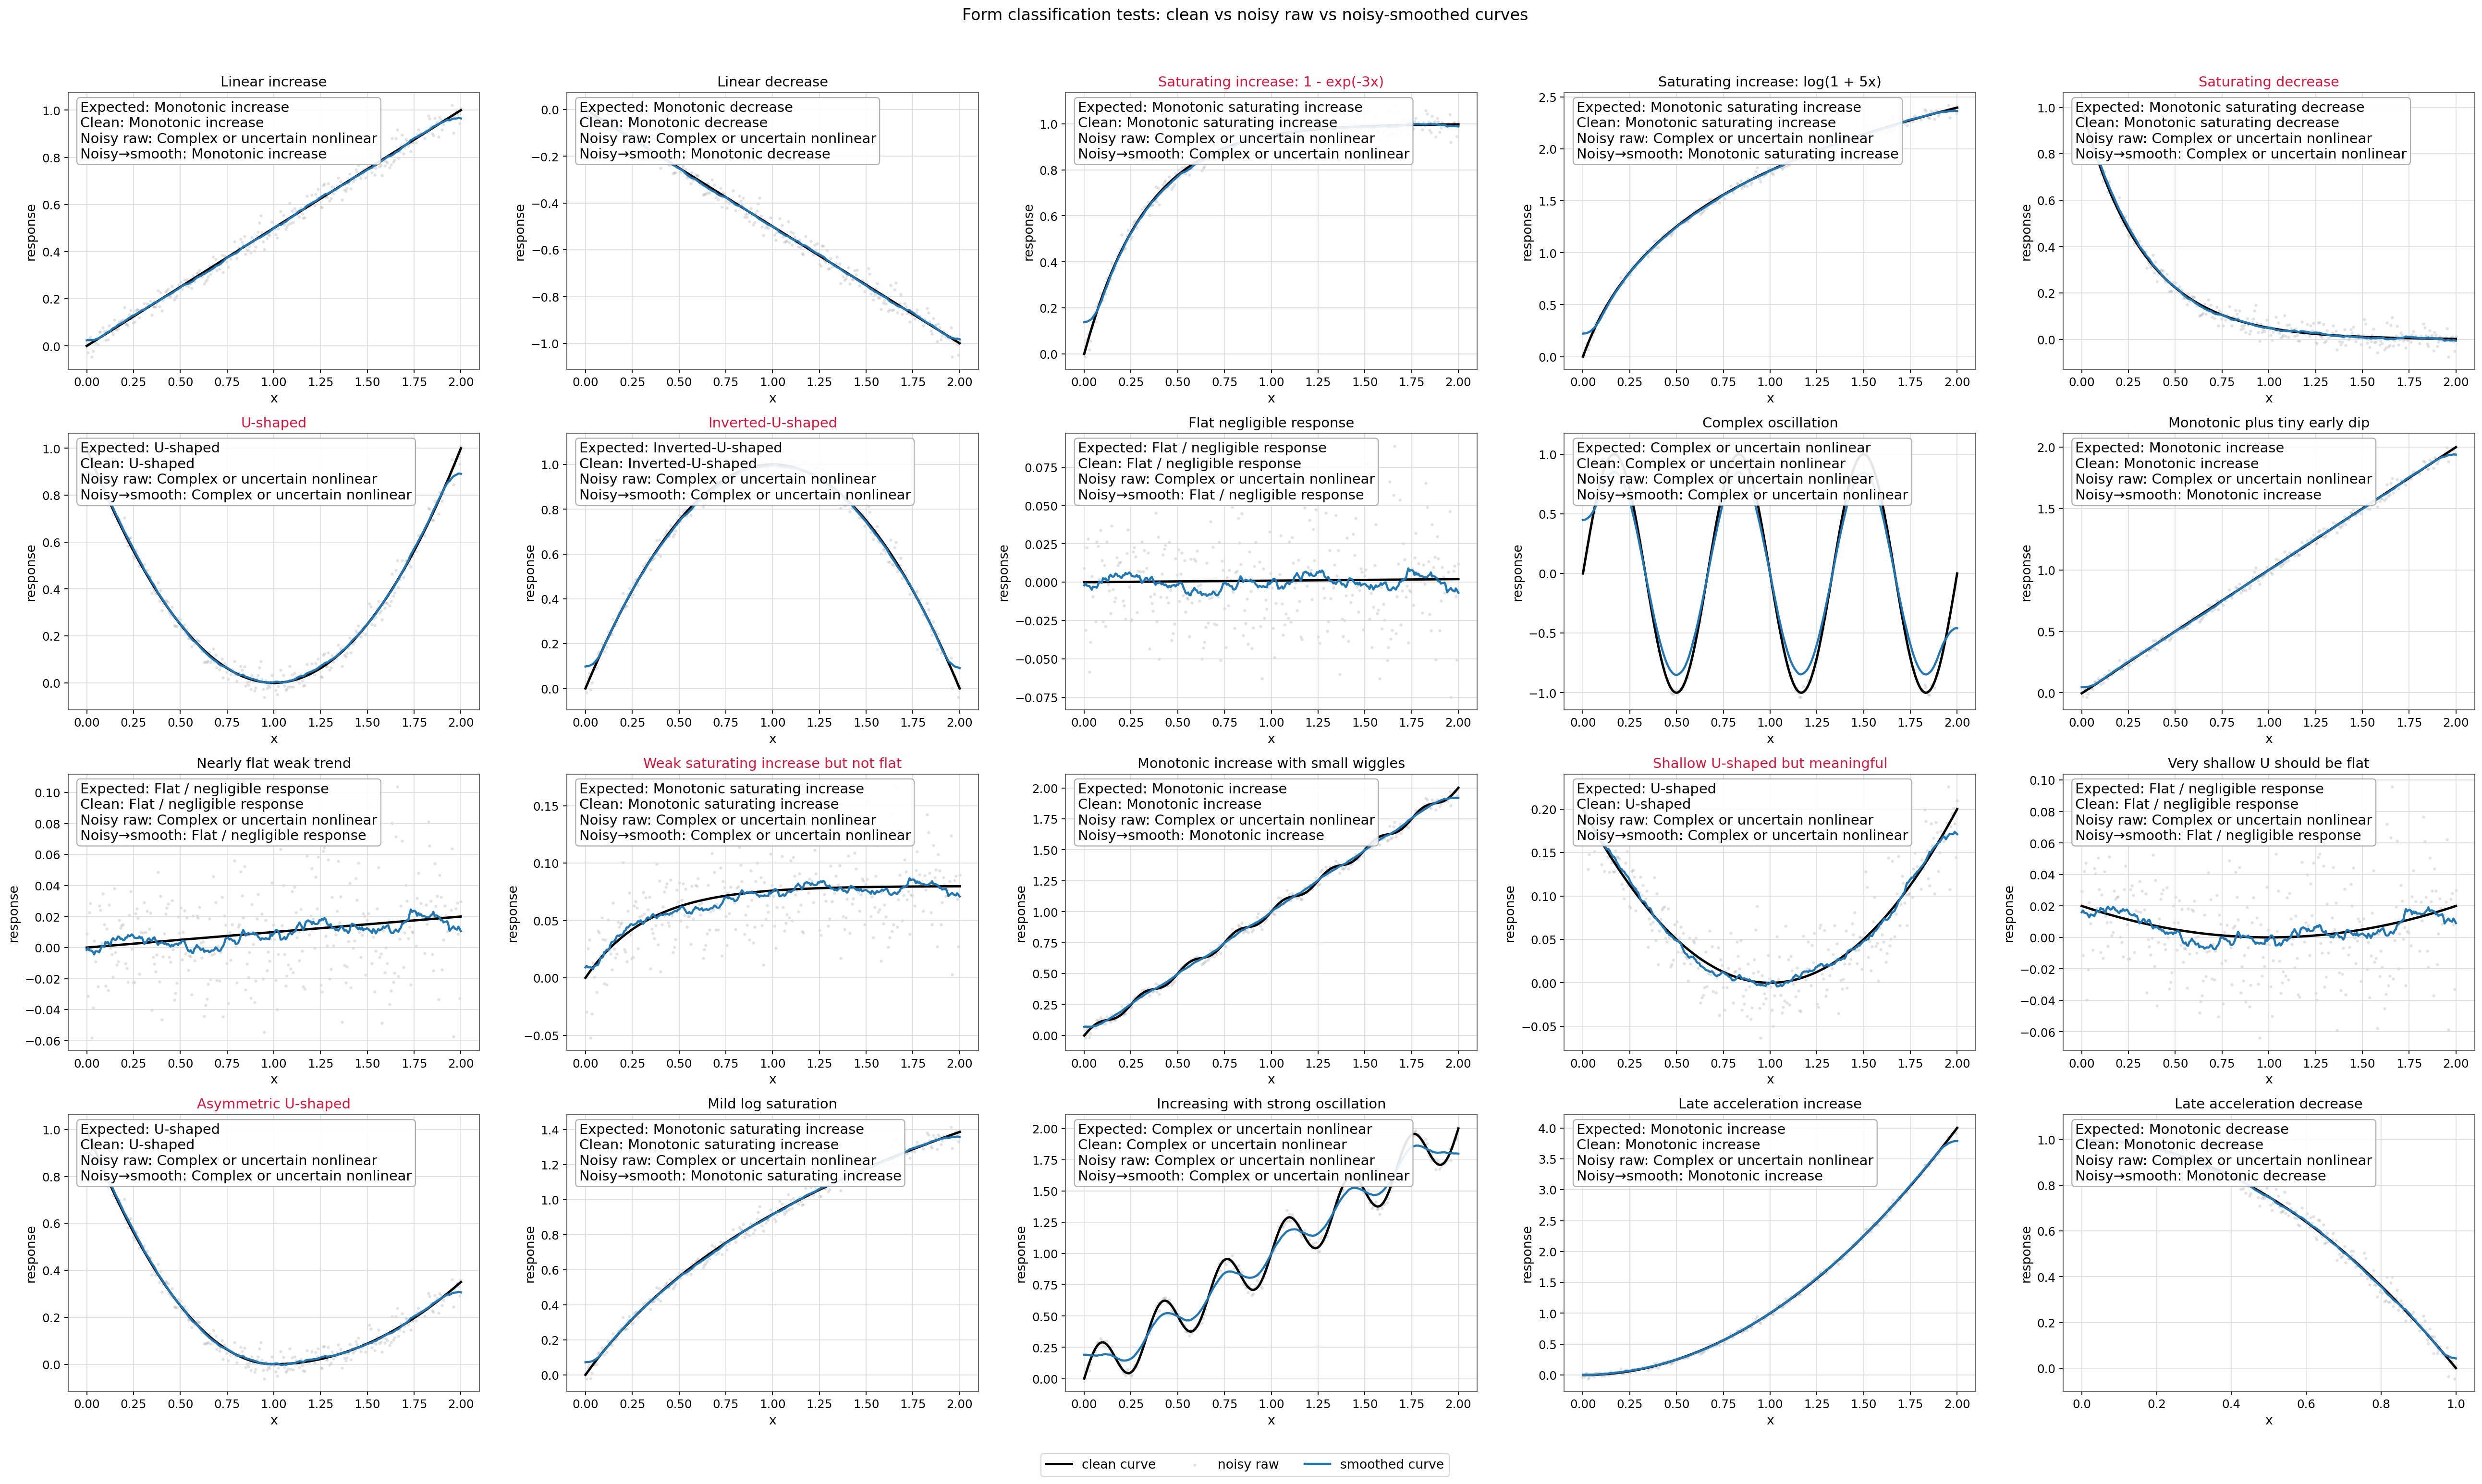

In [20]:
plot_test_comparison(
    test_cases=all_test_cases,
    noise=0.03,
    smooth_window=31,
    n_cols=5,
    figsize_per_panel=(6.5, 4.8),
    text_fontsize=13,
    title_fontsize=13,
    axis_label_fontsize=12,
    tick_fontsize=11,
    legend_fontsize=12
)

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit


# =========================================================
# Label maps
# =========================================================

full_label_map = {
    "P": "Precipitation (mm yr$^{-1}$)",
    "LAI": "Leaf Area Index (m$^2$ m$^{-2}$)",
    "T": "Transpiration (mm yr$^{-1}$)",
    "ET": "Evapotranspiration (mm yr$^{-1}$)",
    "E_veg": "Vegetation Evaporation (mm yr$^{-1}$)",
    "E_soil": "Soil Evaporation (mm yr$^{-1}$)"
}

short_label_map = {
    "P": "Precipitation",
    "LAI": "Leaf Area Index",
    "T": "Transpiration",
    "ET": "Evapotranspiration",
    "E_veg": "Vegetation Evaporation",
    "E_soil": "Soil Evaporation"
}


# =========================================================
# 1. Equal-width binned median curve
# =========================================================

def compute_equal_width_binned_medians(
    x,
    y,
    n_bins=10,
    min_count_per_bin=20
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < min_count_per_bin:
        return None

    x_min, x_max = np.nanmin(x), np.nanmax(x)

    if x_min == x_max:
        return None

    edges = np.linspace(x_min, x_max, n_bins + 1)

    x_med = []
    y_med = []

    for i in range(n_bins):
        left = edges[i]
        right = edges[i + 1]

        if i == n_bins - 1:
            mask = (x >= left) & (x <= right)
        else:
            mask = (x >= left) & (x < right)

        if np.sum(mask) < min_count_per_bin:
            continue

        x_med.append(np.nanmedian(x[mask]))
        y_med.append(np.nanmedian(y[mask]))

    if len(x_med) < 2:
        return None

    return {
        "x": np.asarray(x_med),
        "y": np.asarray(y_med)
    }


# =========================================================
# 2. Equal-count binned median curve
# =========================================================

def compute_equal_count_binned_medians(
    x,
    y,
    n_bins=10,
    min_count_per_bin=20
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < min_count_per_bin:
        return None

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    bin_indices = np.array_split(np.arange(len(x)), n_bins)

    x_med = []
    y_med = []

    for idx in bin_indices:
        if len(idx) < min_count_per_bin:
            continue

        x_med.append(np.nanmedian(x[idx]))
        y_med.append(np.nanmedian(y[idx]))

    if len(x_med) < 2:
        return None

    return {
        "x": np.asarray(x_med),
        "y": np.asarray(y_med)
    }


# =========================================================
# 3. LOWESS curve
# =========================================================

def compute_lowess_curve(
    x,
    y,
    frac=0.18
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5:
        return None

    try:
        smoothed = lowess(
            y,
            x,
            frac=frac,
            return_sorted=True
        )

        xs = smoothed[:, 0]
        uniq_idx = np.concatenate([[True], np.diff(xs) > 0])
        smoothed = smoothed[uniq_idx]

        if len(smoothed) < 2:
            return None

        return {
            "x": smoothed[:, 0],
            "y": smoothed[:, 1]
        }

    except Exception:
        return None


# =========================================================
# 4. Polynomial regression curve
# =========================================================

def compute_polynomial_curve(
    x,
    y,
    degree=3,
    n_grid=300
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < degree + 2:
        return None

    try:
        x_grid = np.linspace(np.nanmin(x), np.nanmax(x), n_grid)

        poly = PolynomialFeatures(
            degree=degree,
            include_bias=False
        )

        X_poly = poly.fit_transform(x.reshape(-1, 1))

        model = LinearRegression()
        model.fit(X_poly, y)

        y_grid = model.predict(
            poly.transform(x_grid.reshape(-1, 1))
        )

        return {
            "x": x_grid,
            "y": y_grid
        }

    except Exception:
        return None


# =========================================================
# 5. GAM curve
# =========================================================

def compute_gam_curve(
    x,
    y,
    n_grid=300,
    n_splines=12
):
    try:
        from pygam import LinearGAM, s
    except ImportError:
        return None

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 20:
        return None

    try:
        x_grid = np.linspace(np.nanmin(x), np.nanmax(x), n_grid)

        gam = LinearGAM(
            s(0, n_splines=n_splines)
        ).fit(
            x.reshape(-1, 1),
            y
        )

        y_grid = gam.predict(x_grid.reshape(-1, 1))

        return {
            "x": x_grid,
            "y": y_grid
        }

    except Exception:
        return None


# =========================================================
# 6. Piecewise linear curve
# =========================================================

def piecewise_linear_one_break(x, x0, k1, k2, b):
    return np.where(
        x < x0,
        k1 * x + b,
        k1 * x0 + b + k2 * (x - x0)
    )


def compute_piecewise_linear_curve(
    x,
    y,
    n_grid=300
):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 20:
        return None

    try:
        x_min = np.nanmin(x)
        x_max = np.nanmax(x)

        x_grid = np.linspace(x_min, x_max, n_grid)

        p0 = [
            np.nanmedian(x),
            0.0,
            0.0,
            np.nanmedian(y)
        ]

        bounds = (
            [x_min, -np.inf, -np.inf, -np.inf],
            [x_max,  np.inf,  np.inf,  np.inf]
        )

        params, _ = curve_fit(
            piecewise_linear_one_break,
            x,
            y,
            p0=p0,
            bounds=bounds,
            maxfev=20000
        )

        y_grid = piecewise_linear_one_break(x_grid, *params)

        return {
            "x": x_grid,
            "y": y_grid
        }

    except Exception:
        return None


# =========================================================
# 7. Symbolic regression curve
# =========================================================

def compute_symbolic_regression_curve(
    x,
    y,
    n_grid=300,
    max_train=8000,
    random_state=42
):
    try:
        from gplearn.genetic import SymbolicRegressor
    except ImportError:
        return None

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 50:
        return None

    try:
        x_grid = np.linspace(np.nanmin(x), np.nanmax(x), n_grid)

        if len(x) > max_train:
            rng = np.random.default_rng(random_state)
            idx = rng.choice(
                len(x),
                size=max_train,
                replace=False
            )

            x_train = x[idx]
            y_train = y[idx]
        else:
            x_train = x
            y_train = y

        est = SymbolicRegressor(
            population_size=1000,
            generations=15,
            stopping_criteria=0.01,
            p_crossover=0.7,
            p_subtree_mutation=0.1,
            p_hoist_mutation=0.05,
            p_point_mutation=0.1,
            max_samples=0.8,
            verbose=0,
            parsimony_coefficient=0.01,
            random_state=random_state,
            function_set=("add", "sub", "mul", "div", "sqrt", "log")
        )

        est.fit(
            x_train.reshape(-1, 1),
            y_train
        )

        y_grid = est.predict(x_grid.reshape(-1, 1))

        return {
            "x": x_grid,
            "y": y_grid,
            "expression": str(est._program)
        }

    except Exception:
        return None


# =========================================================
# 8. Compute all curves for one x-y relation
# =========================================================

def compute_all_curves_for_relation(
    x,
    y,
    n_bins=10,
    min_count_per_bin=20,
    frac=0.18,
    poly_degree=3,
    include_symbolic=False
):
    curves = {}

    curves["Equal-width bins"] = compute_equal_width_binned_medians(
        x,
        y,
        n_bins=n_bins,
        min_count_per_bin=min_count_per_bin
    )

    curves["Equal-count bins"] = compute_equal_count_binned_medians(
        x,
        y,
        n_bins=n_bins,
        min_count_per_bin=min_count_per_bin
    )

    curves["LOWESS"] = compute_lowess_curve(
        x,
        y,
        frac=frac
    )

    curves[f"Polynomial degree {poly_degree}"] = compute_polynomial_curve(
        x,
        y,
        degree=poly_degree
    )

    curves["GAM"] = compute_gam_curve(
        x,
        y
    )

    curves["Piecewise linear"] = compute_piecewise_linear_curve(
        x,
        y
    )

    if include_symbolic:
        curves["Symbolic regression"] = compute_symbolic_regression_curve(
            x,
            y
        )

    curves = {
        method: curve
        for method, curve in curves.items()
        if curve is not None
    }

    return curves


# =========================================================
# 9. Compute ESM curves for 2×2 figure
# =========================================================

def compute_esm_curves_2x2(
    classic_df,
    lpj_df,
    var_map,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="T",
    n_bins=10,
    min_count_per_bin=20,
    frac=0.18,
    poly_degree=3,
    include_symbolic=False
):
    model_specs = [
        ("CLASSIC", classic_df),
        ("LPJ-GUESS", lpj_df)
    ]

    curve_results = {}

    for x_label in x_labels:
        for model_name, df in model_specs:
            df_zone = df[df["climate_zone"] == climate_zone].copy()

            x_col = var_map[x_label]
            y_col = var_map[y_label]

            sub = (
                df_zone[[x_col, y_col]]
                .replace([np.inf, -np.inf], np.nan)
                .dropna()
                .copy()
            )

            x_raw = sub[x_col].values
            y_raw = sub[y_col].values

            curves = compute_all_curves_for_relation(
                x_raw,
                y_raw,
                n_bins=n_bins,
                min_count_per_bin=min_count_per_bin,
                frac=frac,
                poly_degree=poly_degree,
                include_symbolic=include_symbolic
            )

            curve_results[(x_label, y_label, model_name)] = {
                "x_raw": x_raw,
                "y_raw": y_raw,
                "sub": sub,
                "curves": curves,
                "n_points": len(sub)
            }

    return curve_results

In [22]:
def plot_esm_curves_2x2(
    curve_results,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="T",
    model_names=("CLASSIC", "LPJ-GUESS"),
    sample_size=30000,
    point_size=3,
    point_alpha=0.18,
    line_width=1.2,
    n_cols_legend=3
):
    method_styles = {
        "Equal-width bins": {
            "color": "#1f77b4",
            "linestyle": "-"
        },
        "Equal-count bins": {
            "color": "#ff7f0e",
            "linestyle": "-"
        },
        "LOWESS": {
            "color": "#2ca02c",
            "linestyle": "-"
        },
        "Polynomial degree 3": {
            "color": "#d62728",
            "linestyle": "-"
        },
        "GAM": {
            "color": "#9467bd",
            "linestyle": "-"
        },
        "Piecewise linear": {
            "color": "#8c564b",
            "linestyle": "-"
        },
        "Symbolic regression": {
            "color": "#e377c2",
            "linestyle": "-"
        }
    }

    # y-axis limits aligned by row
    y_limits = {}

    for row, x_label in enumerate(x_labels):
        all_y = []

        for model_name in model_names:
            key = (x_label, y_label, model_name)

            if key in curve_results:
                y_raw = curve_results[key]["y_raw"]

                if len(y_raw) > 0:
                    all_y.append(y_raw)

        if len(all_y) > 0:
            y_all = np.concatenate(all_y)

            ymin, ymax = np.nanpercentile(y_all, [1, 99])
            yrange = ymax - ymin

            if yrange == 0:
                yrange = 1

            y_limits[row] = (
                ymin - 0.05 * yrange,
                ymax + 0.05 * yrange
            )

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12, 8),
        dpi=180
    )

    for row, x_label in enumerate(x_labels):
        for col, model_name in enumerate(model_names):
            ax = axes[row, col]

            key = (x_label, y_label, model_name)

            if key not in curve_results:
                continue

            result = curve_results[key]

            x_raw = result["x_raw"]
            y_raw = result["y_raw"]
            sub = result["sub"]
            curves = result["curves"]

            # Scatter sampling
            if len(sub) > sample_size:
                sub_plot = sub.sample(sample_size, random_state=42)
                x_plot = sub_plot.iloc[:, 0].values
                y_plot = sub_plot.iloc[:, 1].values
            else:
                x_plot = x_raw
                y_plot = y_raw

            ax.scatter(
                x_plot,
                y_plot,
                s=point_size,
                alpha=point_alpha,
                color="0.70",
                linewidths=0,
                zorder=1
            )

            # Plot fitted curves
            for method, curve in curves.items():
                style = method_styles.get(
                    method,
                    {
                        "color": "black",
                        "linestyle": "-"
                    }
                )

                ax.plot(
                    curve["x"],
                    curve["y"],
                    color=style["color"],
                    linestyle=style["linestyle"],
                    linewidth=line_width,
                    label=method,
                    zorder=5
                )

            # Model label
            ax.text(
                0.03,
                0.97,
                model_name,
                transform=ax.transAxes,
                fontsize=12,
                fontweight="bold",
                ha="left",
                va="top",
                bbox=dict(
                    boxstyle="round,pad=0.25",
                    facecolor="white",
                    edgecolor="0.65",
                    alpha=0.90
                ),
                zorder=20
            )

            ax.set_xlabel(
                full_label_map.get(x_label, x_label),
                fontsize=12.5
            )

            ax.set_ylabel(
                full_label_map.get(y_label, y_label),
                fontsize=12.5
            )

            if row in y_limits:
                ax.set_ylim(y_limits[row])

            ax.set_title(
                f"{short_label_map.get(x_label, x_label)} → "
                f"{short_label_map.get(y_label, y_label)}",
                fontsize=13,
                pad=9
            )

            ax.set_facecolor("white")
            ax.set_axisbelow(True)
            ax.grid(
                True,
                which="major",
                color="0.82",
                linestyle="-",
                linewidth=0.8
            )
            ax.minorticks_off()

            for side in ["top", "right", "bottom", "left"]:
                ax.spines[side].set_visible(True)
                ax.spines[side].set_linewidth(0.9)
                ax.spines[side].set_color("0.35")

            ax.tick_params(
                axis="both",
                which="major",
                labelsize=10.5,
                length=4,
                width=0.8,
                color="0.35"
            )

    handles, labels = axes[0, 0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=n_cols_legend,
        frameon=True,
        fontsize=10.5,
        bbox_to_anchor=(0.5, -0.01)
    )

    fig.suptitle(
        f"{climate_zone} zone: fitted response curves for "
        f"{short_label_map.get(y_label, y_label)}",
        fontsize=15,
        y=0.98
    )

    plt.tight_layout(rect=[0.03, 0.07, 1, 0.94])
    plt.show()

In [23]:
def classify_esm_curves(
    curve_results,
    classifier=classify_curve_shape
):
    records = []

    for key, result in curve_results.items():
        x_label, y_label, model_name = key

        y_raw = result["y_raw"]

        y_obs_std = np.nanstd(y_raw)

        for method, curve in result["curves"].items():
            shape_result = classifier(
                curve["x"],
                curve["y"],
                y_obs_std=y_obs_std
            )

            records.append({
                "model": model_name,
                "x": x_label,
                "y": y_label,
                "method": method,
                "shape_type": shape_result.get("shape_type", np.nan),
                "n_points": result.get("n_points", np.nan),
                "y_range_to_obs_std": shape_result.get("y_range_to_obs_std", np.nan),
                "net_change": shape_result.get("net_change", np.nan),
                "pos_fraction": shape_result.get("pos_fraction", np.nan),
                "neg_fraction": shape_result.get("neg_fraction", np.nan),
                "flat_fraction": shape_result.get("flat_fraction", np.nan),
                "n_sign_changes": shape_result.get("n_sign_changes", np.nan),
                "early_slope": shape_result.get("early_slope", np.nan),
                "late_slope": shape_result.get("late_slope", np.nan),
                "roughness_ratio": shape_result.get("roughness_ratio", np.nan),
                "increasing_saturation": shape_result.get("increasing_saturation", np.nan),
                "decreasing_saturation": shape_result.get("decreasing_saturation", np.nan),
                "flat_gate_used": shape_result.get("flat_gate_used", np.nan),
            })

    return pd.DataFrame(records)


def make_shape_summary(shape_df):
    shape_summary = shape_df.pivot_table(
        index=["x", "model"],
        columns="method",
        values="shape_type",
        aggfunc="first"
    )

    return shape_summary

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.lines import Line2D
from scipy.stats import spearmanr

# 1. 读取数据
data_dir = Path("./preprocessed/preprocessed_with_zones")

classic_df = pd.read_csv(data_dir / "classic_with_climate_zones_filtered_30yr_mean.csv")
lpj_df = pd.read_csv(data_dir / "lpj_guess_with_climate_zones_filtered_30yr_mean.csv")

# 2. 变量列名映射
var_map = {
    "P": "precipitation",
    "T": "tran",
    "LAI": "lai",
    "ET": "evapotrans",
    "E_veg": "evspsblveg",
    "E_soil": "evspsblsoi"
}

# 3. 核心组合
pairs = [
    ("P", "ET"),
    ("P", "T"),
    ("P", "E_veg"),
    ("P", "E_soil"),
    ("LAI", "ET"),
    ("LAI", "T"),
    ("LAI", "E_veg"),
    ("LAI", "E_soil"),
]

zone_colors = {
    "HW": "#F27D7A",
    "HD": "#EFD447",
    "CW": "#95D98C",
    "CD": "#73AEEB",
}

zone_labels = {
    "HW": "WW - Warm-Wet",
    "HD": "WD - Warm-Dry",
    "CW": "CW - Cold-Wet",
    "CD": "CD - Cold-Dry",
}

# full_label_map = {
#     "P": "Precipitation",
#     "LAI": "Leaf Area Index",
#     "ET": "Evapotranspiration",
#     "T": "Transpiration",
#     "E_veg": "Vegetation Evaporation",
#     "E_soil": "Soil Evaporation"
# }
full_label_map = {
    "P": "Precipitation (mm yr$^{-1}$)",
    "LAI": "Leaf Area Index (m$^2$ m$^{-2}$)",
    "ET": "Evapotranspiration (mm yr$^{-1}$)",
    "T": "Transpiration (mm yr$^{-1}$)",
    "E_veg": "Vegetation Evaporation (mm yr$^{-1}$)",
    "E_soil": "Soil Evaporation (mm yr$^{-1}$)"
}

def compute_binned_medians(x, y, n_bins=10):
    x = np.asarray(x)
    y = np.asarray(y)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) == 0:
        return np.array([]), np.array([])

    order = np.argsort(x)
    x_sorted = x[order]
    y_sorted = y[order]

    # 等样本数分箱
    indices = np.array_split(np.arange(len(x_sorted)), n_bins)

    x_med = []
    y_med = []

    for idx in indices:
        if len(idx) == 0:
            continue
        x_med.append(np.median(x_sorted[idx]))
        y_med.append(np.median(y_sorted[idx]))

    return np.array(x_med), np.array(y_med)

In [25]:
curve_results = compute_esm_curves_2x2(
    classic_df,
    lpj_df,
    var_map=var_map,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="T",
    n_bins=10,
    min_count_per_bin=20,
    frac=0.18,
    poly_degree=3,
    include_symbolic=True
)

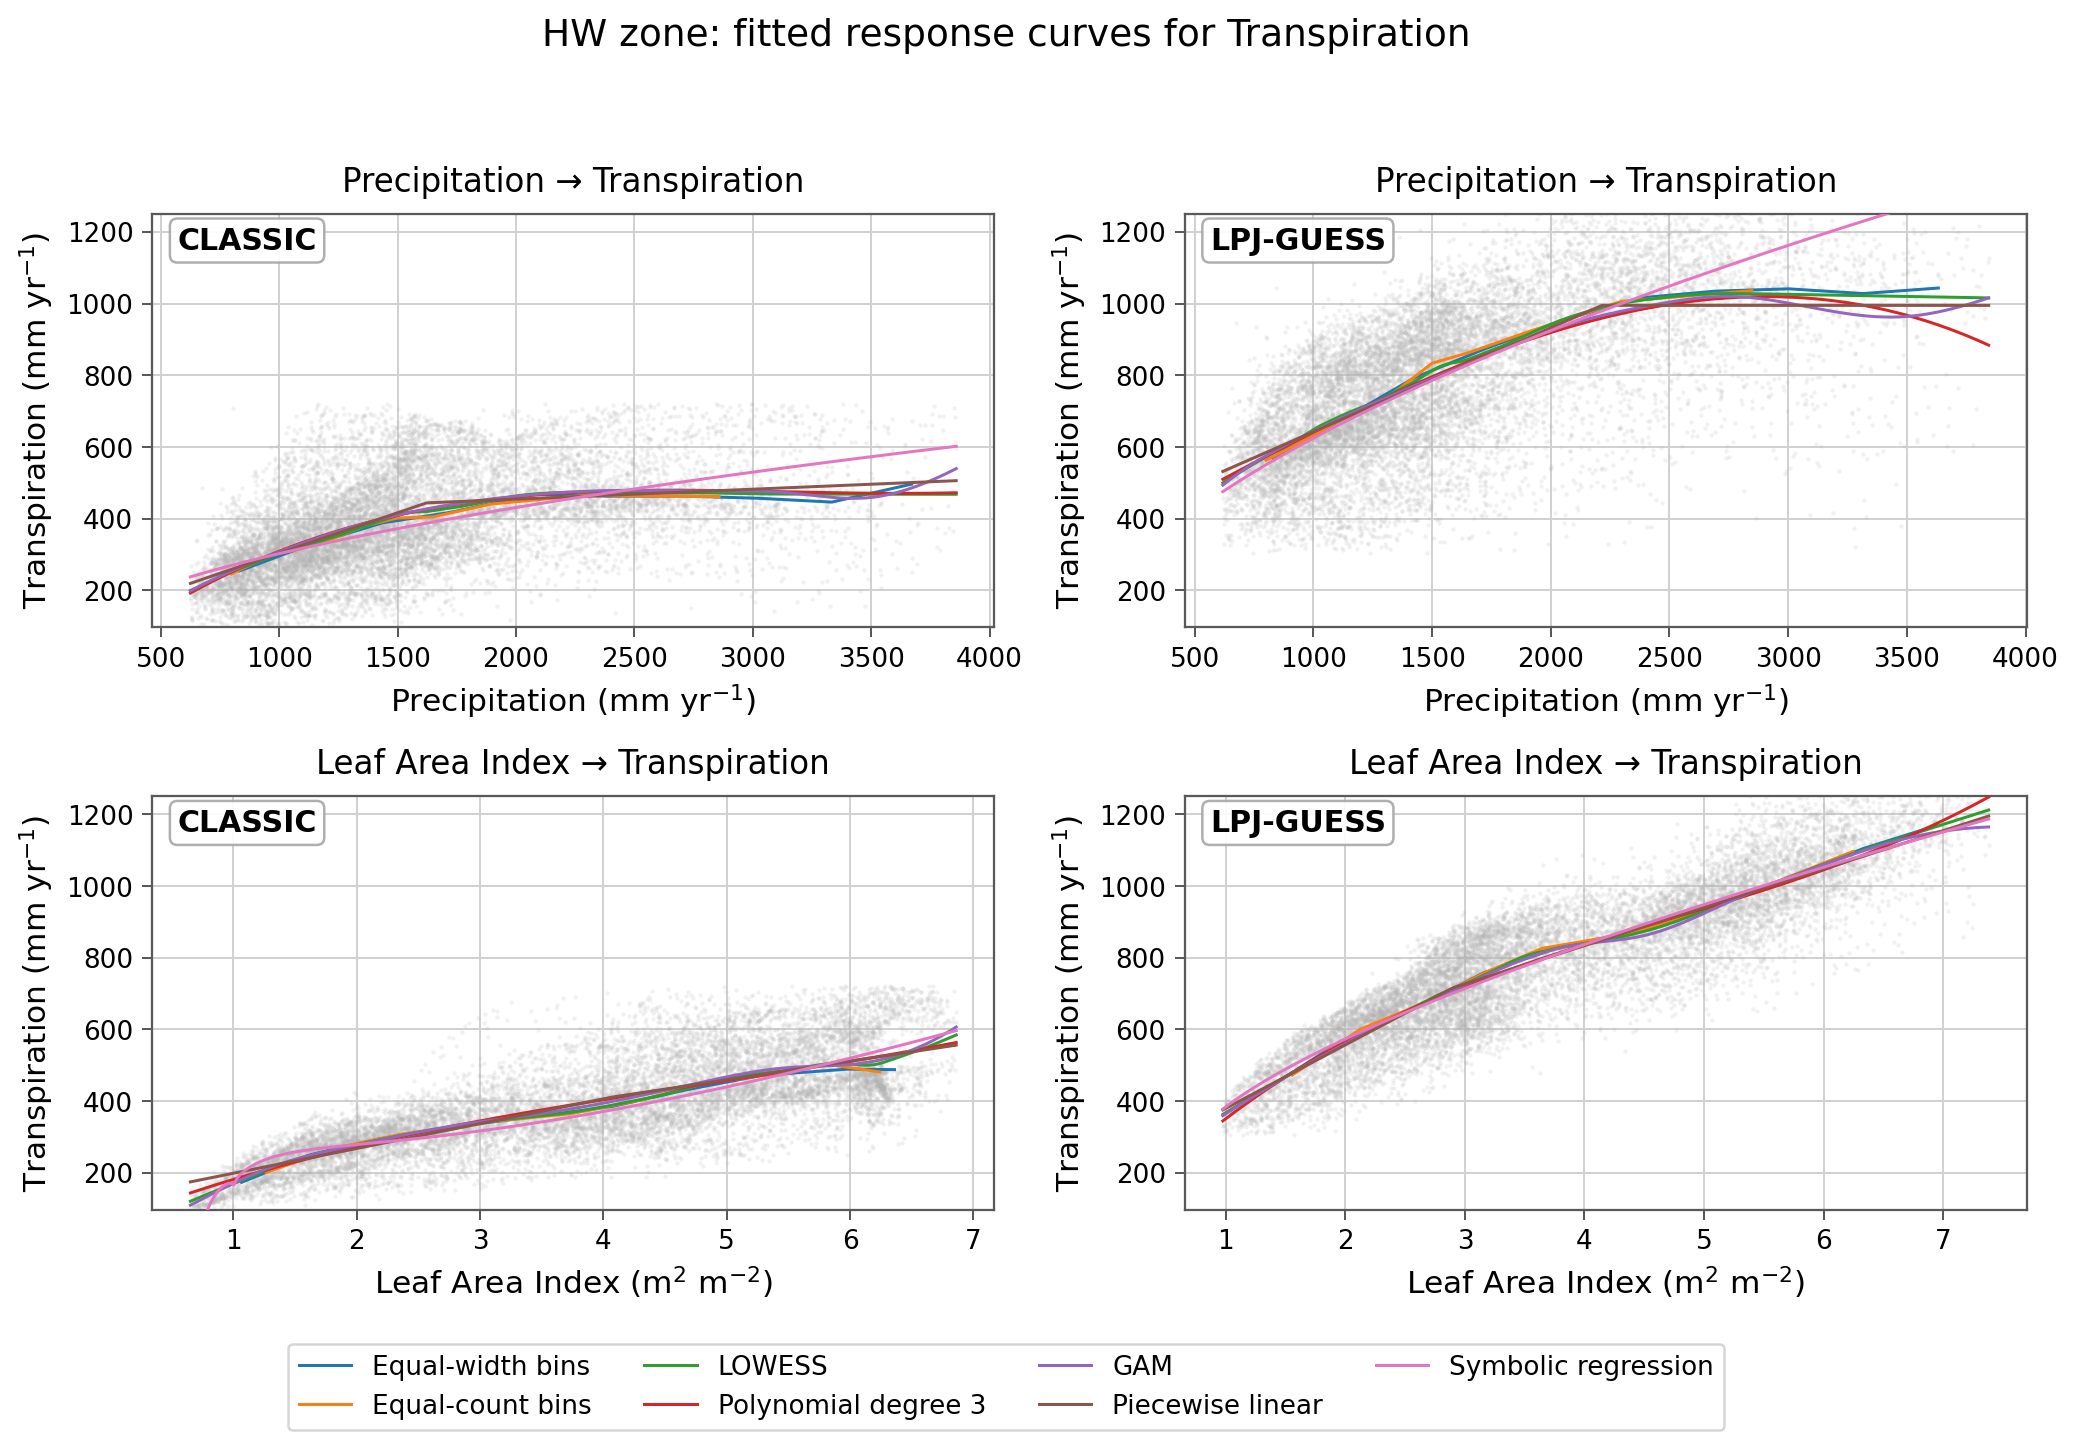

In [26]:
plot_esm_curves_2x2(
    curve_results,
    climate_zone="HW",
    x_labels=("P", "LAI"),
    y_label="T",
    model_names=("CLASSIC", "LPJ-GUESS"),
    line_width=1.2,
    point_alpha=0.18,
    n_cols_legend=4
)

In [27]:
shape_df = classify_esm_curves(curve_results)

shape_df

,model,x,y,method,shape_type,n_points,y_range_to_obs_std,net_change,pos_fraction,neg_fraction,flat_fraction,n_sign_changes,early_slope,late_slope,roughness_ratio,increasing_saturation,decreasing_saturation,flat_gate_used
0,CLASSIC,P,T,Equal-width bins,Complex or uncertain nonlinear,12047,1.845239,1.000000,0.555556,0.333333,0.111111,2,2.349142,-0.223552,1.180302,False,False,True
1,CLASSIC,P,T,Equal-count bins,Monotonic increase,12047,1.668350,0.984962,0.888889,0.111111,0.000000,1,2.222042,-0.054535,1.030536,False,False,True
2,CLASSIC,P,T,LOWESS,Monotonic saturating increase,12047,2.092985,0.978668,0.843693,0.085508,0.070799,15,2.682631,-0.019957,1.043854,True,False,True
3,CLASSIC,P,T,Polynomial degree 3,Complex or uncertain nonlinear,12047,2.187359,0.975363,0.675585,0.267559,0.056856,2,2.617363,-0.116321,1.063615,False,False,True
4,CLASSIC,P,T,GAM,Complex or uncertain nonlinear,12047,2.602444,1.000000,0.702341,0.217391,0.080268,2,2.226584,-0.027121,1.131098,False,False,True
5,CLASSIC,P,T,Piecewise linear,Monotonic saturating increase,12047,2.184151,1.000000,1.000000,0.000000,0.000000,0,2.541910,0.312871,1.000000,True,False,True
6,CLASSIC,P,T,Symbolic regression,Monotonic increase,12047,2.776683,1.000000,1.000000,0.000000,0.000000,0,1.306184,0.750342,1.000000,False,False,True
7,LPJ-GUESS,P,T,Equal-width bins,Monotonic saturating increase,12149,2.308453,1.000000,0.888889,0.111111,0.000000,2,2.158510,0.122631,1.055755,True,False,True
8,LPJ-GUESS,P,T,Equal-count bins,Monotonic saturating increase,12149,2.307539,1.000000,1.000000,0.000000,0.000000,0,1.555071,0.234817,1.000000,True,False,True
9,LPJ-GUESS,P,T,LOWESS,Monotonic increase,12149,2.575243,0.976876,0.937551,0.054869,0.007580,13,2.054432,-0.074594,1.047592,False,False,True


In [28]:
shape_table = shape_df.pivot_table(
    index=["model", "x", "y"],
    columns="method",
    values="shape_type",
    aggfunc="first"
).reset_index()

shape_table

method,model,x,y,Equal-count bins,Equal-width bins,GAM,LOWESS,Piecewise linear,Polynomial degree 3,Symbolic regression
0,CLASSIC,LAI,T,Monotonic increase,Monotonic saturating increase,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase
1,CLASSIC,P,T,Monotonic increase,Complex or uncertain nonlinear,Complex or uncertain nonlinear,Monotonic saturating increase,Monotonic saturating increase,Complex or uncertain nonlinear,Monotonic increase
2,LPJ-GUESS,LAI,T,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase
3,LPJ-GUESS,P,T,Monotonic saturating increase,Monotonic saturating increase,Complex or uncertain nonlinear,Monotonic increase,Monotonic saturating increase,Inverted-U-shaped,Monotonic increase


In [29]:
# 1. 先把 shape_df 复制一份
shape_table_long = shape_df.copy()

# 2. 统一模型名称
shape_table_long["model_short"] = shape_table_long["model"].replace({
    "CLASSIC": "CLASSIC",
    "LPJ-GUESS": "LPJ"
})

# 3. 生成列名：CLASSIC: LAI → T
shape_table_long["relation_col"] = (
    shape_table_long["model_short"]
    + ": "
    + shape_table_long["x"]
    + " \u2192 "
    + shape_table_long["y"]
)

# 4. 方法名称美化
method_name_map = {
    "Equal-width bins": "Equal-width bins",
    "Equal-count bins": "Equal-count bins",
    "LOWESS": "LOWESS",
    "Polynomial degree 3": "Polynomial regression",
    "GAM": "Generalized Additive Model (GAM)",
    "Piecewise linear": "Piecewise linear regression",
    "Symbolic regression": "Symbolic regression"
}

shape_table_long["Method"] = (
    shape_table_long["method"]
    .map(method_name_map)
    .fillna(shape_table_long["method"])
)

# 5. 生成宽表
shape_table_method = shape_table_long.pivot_table(
    index="Method",
    columns="relation_col",
    values="shape_type",
    aggfunc="first"
).reset_index()

# 6. 固定行顺序
method_order = [
    "Equal-width bins",
    "Equal-count bins",
    "LOWESS",
    "Polynomial regression",
    "Generalized Additive Model (GAM)",
    "Piecewise linear regression",
    "Symbolic regression"
]

shape_table_method["Method"] = pd.Categorical(
    shape_table_method["Method"],
    categories=method_order,
    ordered=True
)

shape_table_method = (
    shape_table_method
    .sort_values("Method")
    .reset_index(drop=True)
)

# 7. 固定列顺序
column_order = [
    "Method",
    "CLASSIC: LAI \u2192 T",
    "CLASSIC: P \u2192 T",
    "LPJ: LAI \u2192 T",
    "LPJ: P \u2192 T"
]

available_columns = [
    col for col in column_order
    if col in shape_table_method.columns
]

shape_table_method = shape_table_method[available_columns]

shape_table_method

relation_col,Method,CLASSIC: LAI → T,CLASSIC: P → T,LPJ: LAI → T,LPJ: P → T
0,Equal-width bins,Monotonic saturating increase,Complex or uncertain nonlinear,Monotonic increase,Monotonic saturating increase
1,Equal-count bins,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic saturating increase
2,LOWESS,Monotonic increase,Monotonic saturating increase,Monotonic increase,Monotonic increase
3,Polynomial regression,Monotonic increase,Complex or uncertain nonlinear,Monotonic increase,Inverted-U-shaped
4,Generalized Additive Model (GAM),Monotonic increase,Complex or uncertain nonlinear,Monotonic increase,Complex or uncertain nonlinear
5,Piecewise linear regression,Monotonic increase,Monotonic saturating increase,Monotonic increase,Monotonic saturating increase
6,Symbolic regression,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase


### 先只计算单调、U、以及平坦、以及复杂

In [33]:
import numpy as np
import pandas as pd


def classify_curve_shape_simple(
    x_curve,
    y_curve,
    y_obs_std=None,
    flat_threshold=0.05,
    slope_tol=0.03,
    monotonic_fraction=0.80,
    min_net_change_ratio=0.10,
    turning_amplitude_ratio=0.15,
    roughness_max=3.0,
):
    """
    Simple form classification for fitted response curves.

    Shape labels:
    - Flat / negligible response
    - Monotonic increase
    - Monotonic decrease
    - U-shaped
    - Inverted-U-shaped
    - Complex / uncertain nonlinear

    Intended use:
    Apply to fitted curves, not noisy raw scatter points.
    """

    x = np.asarray(x_curve, dtype=float)
    y = np.asarray(y_curve, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5:
        return {"shape_type": "Insufficient data"}

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    unique_mask = np.concatenate([[True], np.diff(x) > 0])
    x = x[unique_mask]
    y = y[unique_mask]

    if len(x) < 5:
        return {"shape_type": "Insufficient data"}

    x_range = float(np.nanmax(x) - np.nanmin(x))
    y_range_raw = float(np.nanmax(y) - np.nanmin(y))

    if x_range == 0:
        return {"shape_type": "Insufficient data"}

    # 1. Flat / negligible response gate before normalization
    flat_gate_used = (
        y_obs_std is not None
        and np.isfinite(y_obs_std)
        and y_obs_std > 0
    )

    if flat_gate_used:
        y_range_to_obs_std = y_range_raw / y_obs_std

        if y_range_to_obs_std < flat_threshold:
            return {
                "shape_type": "Flat / negligible response",
                "y_range_raw": y_range_raw,
                "y_obs_std": y_obs_std,
                "y_range_to_obs_std": y_range_to_obs_std,
                "flat_gate_used": True,
            }

    elif y_range_raw == 0:
        return {
            "shape_type": "Flat / negligible response",
            "y_range_raw": 0.0,
            "y_obs_std": y_obs_std,
            "y_range_to_obs_std": np.nan,
            "flat_gate_used": False,
        }

    # 2. Normalize x and y
    y_min = float(np.nanmin(y))
    y_range = float(np.nanmax(y) - y_min)

    if y_range == 0:
        return {
            "shape_type": "Flat / negligible response",
            "y_range_raw": y_range_raw,
            "y_obs_std": y_obs_std,
            "y_range_to_obs_std": (
                y_range_raw / y_obs_std if flat_gate_used else np.nan
            ),
            "flat_gate_used": flat_gate_used,
        }

    x_norm = (x - np.nanmin(x)) / x_range
    y_norm = (y - y_min) / y_range

    # 3. Local slopes
    dx = np.diff(x_norm)
    dy = np.diff(y_norm)

    valid_dx = dx != 0
    dx = dx[valid_dx]
    dy = dy[valid_dx]

    if len(dx) < 4:
        return {"shape_type": "Insufficient data"}

    slopes = dy / dx

    signs = np.zeros_like(slopes, dtype=int)
    signs[slopes > slope_tol] = 1
    signs[slopes < -slope_tol] = -1
    signs[np.abs(slopes) <= slope_tol] = 0

    n_segments = len(signs)

    pos_fraction = float(np.sum(signs == 1) / n_segments)
    neg_fraction = float(np.sum(signs == -1) / n_segments)
    flat_fraction = float(np.sum(signs == 0) / n_segments)

    nonzero_signs = signs[signs != 0]

    if len(nonzero_signs) == 0:
        n_sign_changes = 0
        first_sign = 0
        last_sign = 0
    else:
        n_sign_changes = int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))
        first_sign = int(nonzero_signs[0])
        last_sign = int(nonzero_signs[-1])

    # 4. Net change and roughness
    net_change = float(y_norm[-1] - y_norm[0])
    net_change_ratio = abs(net_change)

    total_variation = float(np.sum(np.abs(np.diff(y_norm))))
    roughness_ratio = total_variation / (abs(net_change) + 1e-9)

    mostly_increasing = (
        net_change > min_net_change_ratio
        and pos_fraction + flat_fraction >= monotonic_fraction
    )

    mostly_decreasing = (
        net_change < -min_net_change_ratio
        and neg_fraction + flat_fraction >= monotonic_fraction
    )

    # 5. Turning-point candidates
    min_idx = int(np.argmin(y_norm))
    max_idx = int(np.argmax(y_norm))

    valley_is_internal = 0 < min_idx < len(y_norm) - 1
    peak_is_internal = 0 < max_idx < len(y_norm) - 1

    left_drop_to_min = float(y_norm[0] - y_norm[min_idx])
    right_rise_from_min = float(y_norm[-1] - y_norm[min_idx])

    left_rise_to_max = float(y_norm[max_idx] - y_norm[0])
    right_drop_from_max = float(y_norm[max_idx] - y_norm[-1])

    u_shape_candidate = (
        n_sign_changes == 1
        and first_sign == -1
        and last_sign == 1
        and valley_is_internal
        and left_drop_to_min >= turning_amplitude_ratio
        and right_rise_from_min >= turning_amplitude_ratio
    )

    inverted_u_candidate = (
        n_sign_changes == 1
        and first_sign == 1
        and last_sign == -1
        and peak_is_internal
        and left_rise_to_max >= turning_amplitude_ratio
        and right_drop_from_max >= turning_amplitude_ratio
    )

    # 6. Decision tree
    if u_shape_candidate:
        shape_type = "U-shaped"

    elif inverted_u_candidate:
        shape_type = "Inverted-U-shaped"

    elif mostly_increasing:
        shape_type = "Monotonic increase"

    elif mostly_decreasing:
        shape_type = "Monotonic decrease"

    elif (
        n_sign_changes >= 2
        or roughness_ratio > roughness_max
    ):
        shape_type = "Complex / uncertain nonlinear"

    else:
        shape_type = "Complex / uncertain nonlinear"

    return {
        "shape_type": shape_type,
        "y_range_raw": y_range_raw,
        "y_obs_std": y_obs_std,
        "y_range_to_obs_std": (
            y_range_raw / y_obs_std if flat_gate_used else np.nan
        ),
        "flat_gate_used": flat_gate_used,
        "net_change": net_change,
        "net_change_ratio": net_change_ratio,
        "pos_fraction": pos_fraction,
        "neg_fraction": neg_fraction,
        "flat_fraction": flat_fraction,
        "n_sign_changes": n_sign_changes,
        "first_sign": first_sign,
        "last_sign": last_sign,
        "roughness_ratio": roughness_ratio,
        "left_drop_to_min": left_drop_to_min,
        "right_rise_from_min": right_rise_from_min,
        "left_rise_to_max": left_rise_to_max,
        "right_drop_from_max": right_drop_from_max,
        "u_shape_candidate": u_shape_candidate,
        "inverted_u_candidate": inverted_u_candidate,
    }

In [34]:
def classify_esm_curves_simple(curve_results):
    records = []

    for key, result in curve_results.items():
        x_label, y_label, model_name = key

        y_raw = result["y_raw"]
        y_obs_std = np.nanstd(y_raw)

        for method, curve in result["curves"].items():
            shape_result = classify_curve_shape_simple(
                curve["x"],
                curve["y"],
                y_obs_std=y_obs_std
            )

            records.append({
                "model": model_name,
                "x": x_label,
                "y": y_label,
                "method": method,
                "shape_type": shape_result.get("shape_type", np.nan),
                "y_range_to_obs_std": shape_result.get("y_range_to_obs_std", np.nan),
                "net_change": shape_result.get("net_change", np.nan),
                "pos_fraction": shape_result.get("pos_fraction", np.nan),
                "neg_fraction": shape_result.get("neg_fraction", np.nan),
                "flat_fraction": shape_result.get("flat_fraction", np.nan),
                "n_sign_changes": shape_result.get("n_sign_changes", np.nan),
                "roughness_ratio": shape_result.get("roughness_ratio", np.nan),
            })

    return pd.DataFrame(records)

In [35]:
shape_df_simple = classify_esm_curves_simple(curve_results)

shape_table_simple = shape_df_simple.pivot_table(
    index=["model", "x", "y"],
    columns="method",
    values="shape_type",
    aggfunc="first"
).reset_index()

shape_table_simple

method,model,x,y,Equal-count bins,Equal-width bins,GAM,LOWESS,Piecewise linear,Polynomial degree 3,Symbolic regression
0,CLASSIC,LAI,T,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase
1,CLASSIC,P,T,Monotonic increase,Complex / uncertain nonlinear,Complex / uncertain nonlinear,Monotonic increase,Monotonic increase,Complex / uncertain nonlinear,Monotonic increase
2,LPJ-GUESS,LAI,T,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase
3,LPJ-GUESS,P,T,Monotonic increase,Monotonic increase,Complex / uncertain nonlinear,Monotonic increase,Monotonic increase,Inverted-U-shaped,Monotonic increase


In [36]:
shape_table_long = shape_df_simple.copy()

shape_table_long["model_short"] = shape_table_long["model"].replace({
    "CLASSIC": "CLASSIC",
    "LPJ-GUESS": "LPJ"
})

shape_table_long["relation_col"] = (
    shape_table_long["model_short"]
    + ": "
    + shape_table_long["x"]
    + " \u2192 "
    + shape_table_long["y"]
)

method_name_map = {
    "Equal-width bins": "Equal-width bins",
    "Equal-count bins": "Equal-count bins",
    "LOWESS": "LOWESS",
    "Polynomial degree 3": "Polynomial regression",
    "GAM": "Generalized Additive Model (GAM)",
    "Piecewise linear": "Piecewise linear regression",
    "Symbolic regression": "Symbolic regression"
}

shape_table_long["Method"] = (
    shape_table_long["method"]
    .map(method_name_map)
    .fillna(shape_table_long["method"])
)

shape_table_method_simple = shape_table_long.pivot_table(
    index="Method",
    columns="relation_col",
    values="shape_type",
    aggfunc="first"
).reset_index()

method_order = [
    "Equal-width bins",
    "Equal-count bins",
    "LOWESS",
    "Polynomial regression",
    "Generalized Additive Model (GAM)",
    "Piecewise linear regression",
    "Symbolic regression"
]

shape_table_method_simple["Method"] = pd.Categorical(
    shape_table_method_simple["Method"],
    categories=method_order,
    ordered=True
)

shape_table_method_simple = (
    shape_table_method_simple
    .sort_values("Method")
    .reset_index(drop=True)
)

column_order = [
    "Method",
    "CLASSIC: LAI \u2192 T",
    "CLASSIC: P \u2192 T",
    "LPJ: LAI \u2192 T",
    "LPJ: P \u2192 T"
]

available_columns = [
    col for col in column_order
    if col in shape_table_method_simple.columns
]

shape_table_method_simple = shape_table_method_simple[available_columns]

shape_table_method_simple

relation_col,Method,CLASSIC: LAI → T,CLASSIC: P → T,LPJ: LAI → T,LPJ: P → T
0,Equal-width bins,Monotonic increase,Complex / uncertain nonlinear,Monotonic increase,Monotonic increase
1,Equal-count bins,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase
2,LOWESS,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase
3,Polynomial regression,Monotonic increase,Complex / uncertain nonlinear,Monotonic increase,Inverted-U-shaped
4,Generalized Additive Model (GAM),Monotonic increase,Complex / uncertain nonlinear,Monotonic increase,Complex / uncertain nonlinear
5,Piecewise linear regression,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase
6,Symbolic regression,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase


测试数据

In [37]:
import numpy as np
import pandas as pd


# =========================================================
# Synthetic test data
# =========================================================

def make_curve(func, x_range=(0, 1), n=120, noise=0.0, seed=0):
    rng = np.random.default_rng(seed)
    x = np.linspace(*x_range, n)
    y_true = func(x)
    y = y_true + noise * rng.standard_normal(n)
    return x, y, y_true


Y_OBS_STD = 1.0


basic_test_cases_simple = [
    (
        "Linear increase",
        lambda x: 0.5 * x,
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Linear decrease",
        lambda x: -0.5 * x,
        (0, 2),
        "Monotonic decrease",
    ),
    (
        "Saturating increase: 1 - exp(-3x)",
        lambda x: 1 - np.exp(-3 * x),
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Saturating increase: log(1 + 5x)",
        lambda x: np.log(1 + 5 * x),
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Saturating decrease",
        lambda x: np.exp(-3 * x),
        (0, 2),
        "Monotonic decrease",
    ),
    (
        "U-shaped",
        lambda x: (x - 1.0) ** 2,
        (0, 2),
        "U-shaped",
    ),
    (
        "Inverted-U-shaped",
        lambda x: 1.0 - (x - 1.0) ** 2,
        (0, 2),
        "Inverted-U-shaped",
    ),
    (
        "Flat negligible response",
        lambda x: 0.001 * x,
        (0, 2),
        "Flat / negligible response",
    ),
    (
        "Complex oscillation",
        lambda x: np.sin(3 * np.pi * x),
        (0, 2),
        "Complex / uncertain nonlinear",
    ),
]


edge_test_cases_simple = [
    (
        "Monotonic plus tiny early dip",
        lambda x: x - 0.005 * np.exp(-50 * (x - 0.05) ** 2),
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Nearly flat weak trend",
        lambda x: 0.01 * x,
        (0, 2),
        "Flat / negligible response",
    ),
    (
        "Weak saturating increase but not flat",
        lambda x: 0.08 * (1 - np.exp(-3 * x)),
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Monotonic increase with small wiggles",
        lambda x: x + 0.03 * np.sin(8 * np.pi * x),
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Shallow U-shaped but meaningful",
        lambda x: 0.20 * (x - 1.0) ** 2,
        (0, 2),
        "U-shaped",
    ),
    (
        "Very shallow U should be flat",
        lambda x: 0.02 * (x - 1.0) ** 2,
        (0, 2),
        "Flat / negligible response",
    ),
    (
        "Asymmetric U-shaped",
        lambda x: np.where(
            x < 1.0,
            (x - 1.0) ** 2,
            0.35 * (x - 1.0) ** 2
        ),
        (0, 2),
        "U-shaped",
    ),
    (
        "Mild log saturation",
        lambda x: np.log1p(1.5 * x),
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Increasing with strong oscillation",
        lambda x: x + 0.20 * np.sin(6 * np.pi * x),
        (0, 2),
        "Complex / uncertain nonlinear",
    ),
    (
        "Late acceleration increase",
        lambda x: x ** 2,
        (0, 2),
        "Monotonic increase",
    ),
    (
        "Late acceleration decrease",
        lambda x: 1 - x ** 2,
        (0, 1),
        "Monotonic decrease",
    ),
]


all_test_cases_simple = basic_test_cases_simple + edge_test_cases_simple


# =========================================================
# Optional smoothing for noisy fitted-curve simulation
# =========================================================

def smooth_curve_moving_average(y, window=31):
    y = np.asarray(y, dtype=float)

    if window is None or window <= 1:
        return y.copy()

    if window >= len(y):
        window = len(y) - 1 if len(y) % 2 == 0 else len(y)

    if window < 3:
        return y.copy()

    if window % 2 == 0:
        window += 1

    pad = window // 2
    kernel = np.ones(window) / window
    y_pad = np.pad(y, pad_width=pad, mode="reflect")
    y_smooth = np.convolve(y_pad, kernel, mode="valid")

    return y_smooth


# =========================================================
# Test runners
# =========================================================

def print_test_summary_simple(df, title):
    n_pass = int(df["ok"].sum())
    n_total = len(df)

    print("\n" + "=" * 120)
    print(title)
    print("=" * 120)
    print(f"Pass rate: {n_pass}/{n_total} = {100 * n_pass / n_total:.1f}%")

    failed = df[df["ok"] == False]

    if len(failed) > 0:
        print("\nFailed cases:")
        display_cols = [
            "test_name",
            "expected",
            "got",
            "net_change",
            "pos_fraction",
            "neg_fraction",
            "flat_fraction",
            "n_sign_changes",
            "roughness_ratio",
            "y_range_to_obs_std"
        ]
        display_cols = [c for c in display_cols if c in failed.columns]
        print(failed[display_cols].to_string(index=False))
    else:
        print("All tests passed.")


def run_clean_tests_simple(test_cases=all_test_cases_simple):
    rows = []

    for name, func, xr, expected in test_cases:
        x, y, y_true = make_curve(
            func,
            x_range=xr,
            n=120,
            noise=0.0
        )

        result = classify_curve_shape_simple(
            x,
            y,
            y_obs_std=Y_OBS_STD
        )

        got = result["shape_type"]
        ok = got == expected

        rows.append({
            "test_group": "clean_curve",
            "test_name": name,
            "expected": expected,
            "got": got,
            "ok": ok,
            **result
        })

    df = pd.DataFrame(rows)
    print_test_summary_simple(df, "Clean fitted curves")
    return df


def run_noisy_raw_tests_simple(
    test_cases=all_test_cases_simple,
    noise=0.03,
    seed=42
):
    rows = []

    for name, func, xr, expected in test_cases:
        x, y_noisy, y_true = make_curve(
            func,
            x_range=xr,
            n=120,
            noise=noise,
            seed=seed
        )

        result = classify_curve_shape_simple(
            x,
            y_noisy,
            y_obs_std=Y_OBS_STD
        )

        got = result["shape_type"]
        ok = got == expected

        rows.append({
            "test_group": "noisy_raw_curve",
            "test_name": name,
            "expected": expected,
            "got": got,
            "ok": ok,
            "noise": noise,
            **result
        })

    df = pd.DataFrame(rows)
    print_test_summary_simple(df, f"Noisy raw curves, noise={noise}")
    return df


def run_noisy_smoothed_tests_simple(
    test_cases=all_test_cases_simple,
    noise=0.03,
    seed=42,
    smooth_window=31
):
    rows = []

    for name, func, xr, expected in test_cases:
        x, y_noisy, y_true = make_curve(
            func,
            x_range=xr,
            n=300,
            noise=noise,
            seed=seed
        )

        y_fit = smooth_curve_moving_average(
            y_noisy,
            window=smooth_window
        )

        x_curve = x[::3]
        y_curve = y_fit[::3]

        result = classify_curve_shape_simple(
            x_curve,
            y_curve,
            y_obs_std=Y_OBS_STD
        )

        got = result["shape_type"]
        ok = got == expected

        rows.append({
            "test_group": "noisy_smoothed_curve",
            "test_name": name,
            "expected": expected,
            "got": got,
            "ok": ok,
            "noise": noise,
            "smooth_window": smooth_window,
            **result
        })

    df = pd.DataFrame(rows)
    print_test_summary_simple(df, f"Noisy → smoothed curves, noise={noise}")
    return df


def compare_test_results_simple(*dfs):
    compare_df = pd.concat(dfs, ignore_index=True)

    summary = (
        compare_df
        .groupby("test_group")["ok"]
        .agg(["sum", "count"])
        .reset_index()
    )

    summary["pass_rate"] = summary["sum"] / summary["count"]
    summary["pass_rate_percent"] = (summary["pass_rate"] * 100).round(1)

    return compare_df, summary


# =========================================================
# Run tests
# =========================================================

clean_df_simple = run_clean_tests_simple()

noisy_raw_df_simple = run_noisy_raw_tests_simple(
    noise=0.03
)

noisy_smoothed_df_simple = run_noisy_smoothed_tests_simple(
    noise=0.03,
    smooth_window=31
)

compare_df_simple, summary_df_simple = compare_test_results_simple(
    clean_df_simple,
    noisy_raw_df_simple,
    noisy_smoothed_df_simple
)

summary_df_simple


Clean fitted curves
Pass rate: 20/20 = 100.0%
All tests passed.

Noisy raw curves, noise=0.03
Pass rate: 3/20 = 15.0%

Failed cases:
                            test_name                   expected                           got  net_change  pos_fraction  neg_fraction  flat_fraction  n_sign_changes  roughness_ratio  y_range_to_obs_std
                      Linear increase         Monotonic increase Complex / uncertain nonlinear    0.924016      0.638655      0.352941       0.008403              72         3.336469            1.064568
                      Linear decrease         Monotonic decrease Complex / uncertain nonlinear   -1.000000      0.403361      0.596639       0.000000              76         3.134888            1.016322
    Saturating increase: 1 - exp(-3x)         Monotonic increase Complex / uncertain nonlinear    0.946825      0.647059      0.344538       0.008403              67         3.415097            1.036305
     Saturating increase: log(1 + 5x)         Monotoni

,test_group,sum,count,pass_rate,pass_rate_percent
0,clean_curve,20,20,1.00,100.0
1,noisy_raw_curve,3,20,0.15,15.0
2,noisy_smoothed_curve,15,20,0.75,75.0


In [38]:
import math
import numpy as np
import matplotlib.pyplot as plt


def plot_test_comparison_simple(
    test_cases=all_test_cases_simple,
    noise=0.03,
    smooth_window=31,
    n_cols=2,
    figsize_per_panel=(6.5, 4.8),
    seed=42,
    title_fontsize=13,
    text_fontsize=10.5,
    axis_label_fontsize=11.5,
    tick_fontsize=10.5,
    legend_fontsize=11.5
):
    """
    Plot synthetic form-classification tests:
    clean curve vs noisy raw curve vs noisy-smoothed curve.
    """

    n_cases = len(test_cases)
    n_rows = math.ceil(n_cases / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(figsize_per_panel[0] * n_cols, figsize_per_panel[1] * n_rows),
        dpi=160
    )

    axes = np.asarray(axes).reshape(-1)

    for i, (name, func, xr, expected) in enumerate(test_cases):
        ax = axes[i]

        # Clean curve
        x_clean, y_clean, _ = make_curve(
            func,
            x_range=xr,
            n=300,
            noise=0.0
        )

        # Noisy raw curve
        x_noisy, y_noisy, _ = make_curve(
            func,
            x_range=xr,
            n=300,
            noise=noise,
            seed=seed
        )

        # Smoothed fitted curve from noisy data
        y_smooth = smooth_curve_moving_average(
            y_noisy,
            window=smooth_window
        )

        # Classification
        clean_result = classify_curve_shape_simple(
            x_clean,
            y_clean,
            y_obs_std=Y_OBS_STD
        )

        noisy_result = classify_curve_shape_simple(
            x_noisy,
            y_noisy,
            y_obs_std=Y_OBS_STD
        )

        smooth_result = classify_curve_shape_simple(
            x_noisy,
            y_smooth,
            y_obs_std=Y_OBS_STD
        )

        clean_label = clean_result["shape_type"]
        noisy_label = noisy_result["shape_type"]
        smooth_label = smooth_result["shape_type"]

        # Plot
        ax.plot(
            x_clean,
            y_clean,
            linewidth=2.2,
            color="black",
            label="Clean curve",
            zorder=3
        )

        ax.scatter(
            x_noisy,
            y_noisy,
            s=9,
            alpha=0.25,
            color="0.55",
            linewidths=0,
            label="Noisy raw",
            zorder=1
        )

        ax.plot(
            x_noisy,
            y_smooth,
            linewidth=2.0,
            color="tab:blue",
            label="Noisy → smoothed",
            zorder=4
        )

        # Text box
        text = (
            f"Expected: {expected}\n"
            f"Clean: {clean_label}\n"
            f"Noisy raw: {noisy_label}\n"
            f"Noisy→smooth: {smooth_label}"
        )

        ok_clean = clean_label == expected
        ok_smooth = smooth_label == expected

        title_color = "black" if ok_clean and ok_smooth else "crimson"

        ax.text(
            0.03,
            0.97,
            text,
            transform=ax.transAxes,
            ha="left",
            va="top",
            fontsize=text_fontsize,
            bbox=dict(
                boxstyle="round,pad=0.25",
                facecolor="white",
                edgecolor="0.65",
                alpha=0.90
            ),
            zorder=10
        )

        ax.set_title(
            name,
            fontsize=title_fontsize,
            color=title_color,
            pad=8
        )

        ax.set_xlabel("x", fontsize=axis_label_fontsize)
        ax.set_ylabel("response", fontsize=axis_label_fontsize)

        ax.grid(
            True,
            which="major",
            color="0.85",
            linewidth=0.7
        )

        for side in ["top", "right", "bottom", "left"]:
            ax.spines[side].set_visible(True)
            ax.spines[side].set_linewidth(0.8)
            ax.spines[side].set_color("0.35")

        ax.tick_params(
            axis="both",
            labelsize=tick_fontsize,
            length=3.5,
            width=0.8,
            color="0.35"
        )

    # Hide unused subplots
    for j in range(n_cases, len(axes)):
        axes[j].axis("off")

    # Shared legend
    handles, labels = axes[0].get_legend_handles_labels()

    fig.legend(
        handles,
        labels,
        loc="lower center",
        ncol=3,
        fontsize=legend_fontsize,
        frameon=True,
        bbox_to_anchor=(0.5, -0.005)
    )

    fig.suptitle(
        "Simple form classification tests: clean vs noisy raw vs noisy-smoothed curves",
        fontsize=16,
        y=0.995
    )

    plt.tight_layout(rect=[0, 0.025, 1, 0.975])
    plt.show()

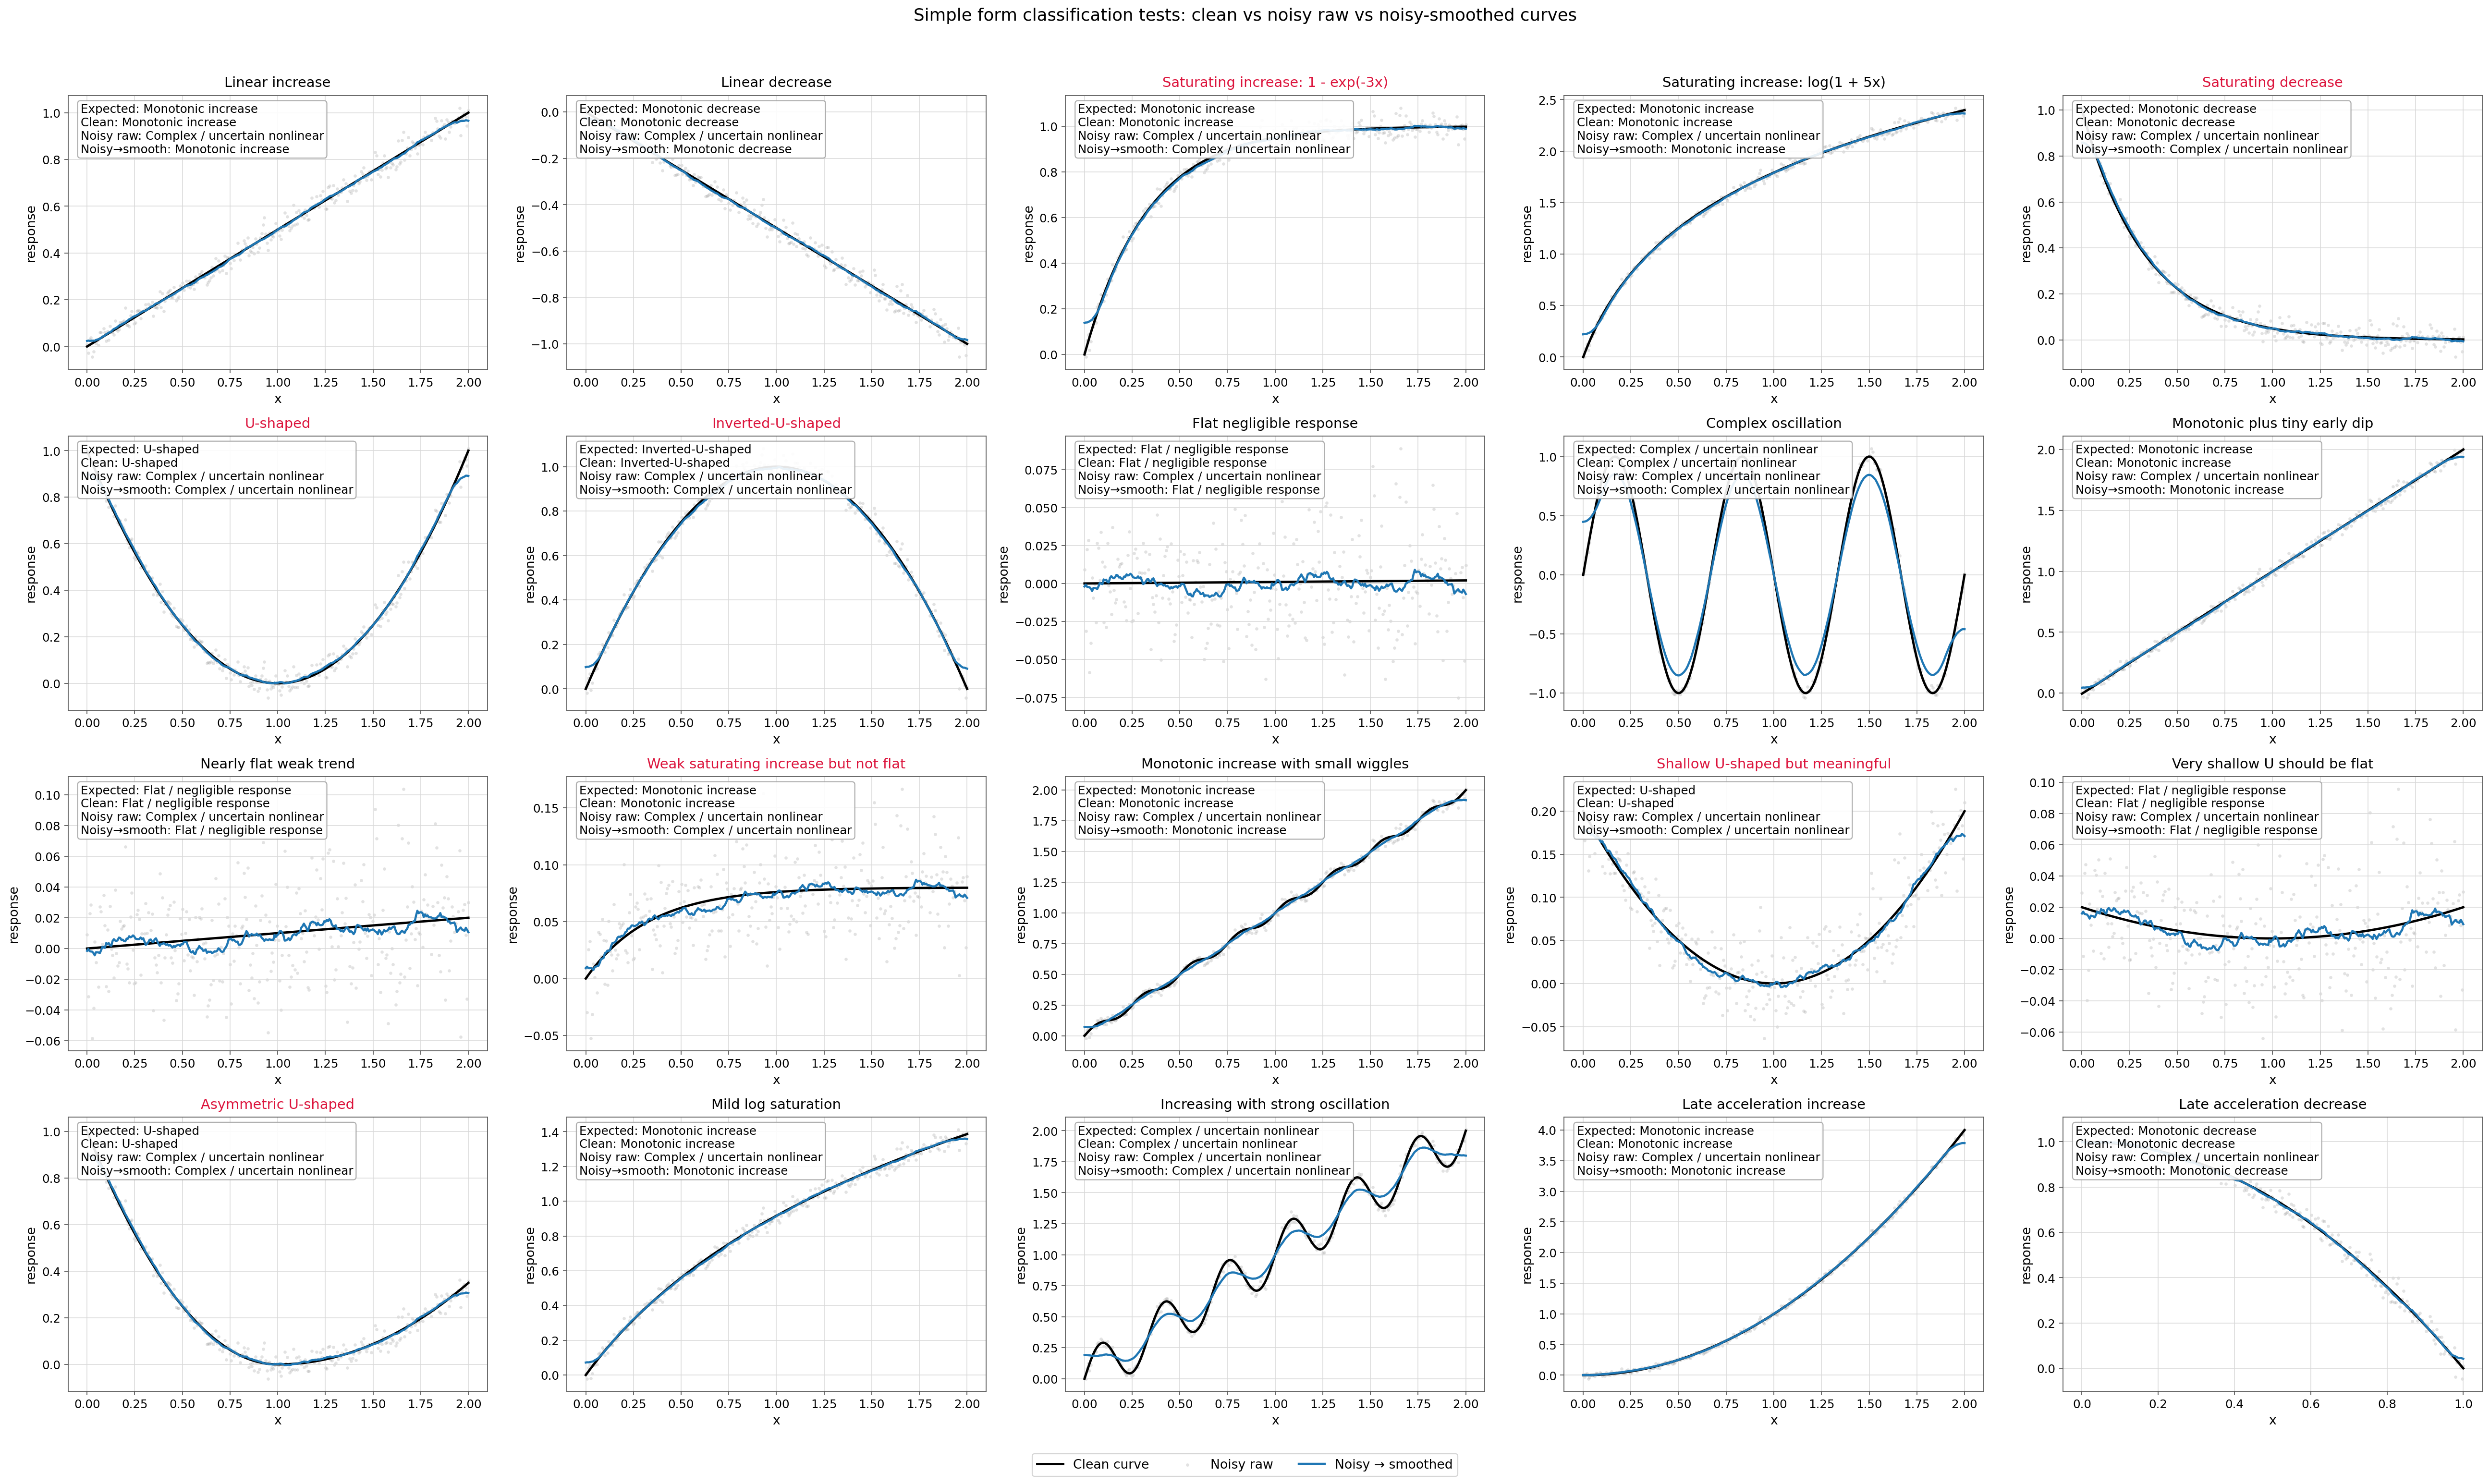

In [40]:
plot_test_comparison_simple(
    test_cases=all_test_cases_simple,
    noise=0.03,
    smooth_window=31,
    n_cols=5,
    figsize_per_panel=(6.5, 4.8),
    text_fontsize=11,
    title_fontsize=13,
    axis_label_fontsize=12,
    tick_fontsize=11,
    legend_fontsize=12
)

In [66]:
import numpy as np
import pandas as pd


def classify_curve_shape_simple(
    x_curve,
    y_curve,
    y_obs_std=None,
    flat_threshold=0.05,
    slope_tol=0.03,
    monotonic_fraction=0.70,
    min_net_change_ratio=0.10,
    turning_amplitude_ratio=0.10,
    side_fraction_threshold=0.60,
    roughness_max=3.0,
):
    """
    Simplified and more tolerant form classification for fitted response curves.

    Shape labels:
    - Flat / negligible response
    - Monotonic increase
    - Monotonic decrease
    - U-shaped
    - Inverted-U-shaped
    - Complex / uncertain nonlinear

    Intended use:
    Apply to fitted curves, not directly to noisy raw scatter points.
    """

    # -----------------------------------------------------
    # 1. Input cleaning
    # -----------------------------------------------------
    x = np.asarray(x_curve, dtype=float)
    y = np.asarray(y_curve, dtype=float)

    valid = np.isfinite(x) & np.isfinite(y)
    x = x[valid]
    y = y[valid]

    if len(x) < 5:
        return {"shape_type": "Insufficient data"}

    order = np.argsort(x)
    x = x[order]
    y = y[order]

    unique_mask = np.concatenate([[True], np.diff(x) > 0])
    x = x[unique_mask]
    y = y[unique_mask]

    if len(x) < 5:
        return {"shape_type": "Insufficient data"}

    x_range = float(np.nanmax(x) - np.nanmin(x))
    y_range_raw = float(np.nanmax(y) - np.nanmin(y))

    if x_range == 0:
        return {"shape_type": "Insufficient data"}

    # -----------------------------------------------------
    # 2. Flat / negligible response gate before normalization
    # -----------------------------------------------------
    flat_gate_used = (
        y_obs_std is not None
        and np.isfinite(y_obs_std)
        and y_obs_std > 0
    )

    if flat_gate_used:
        y_range_to_obs_std = y_range_raw / y_obs_std

        if y_range_to_obs_std < flat_threshold:
            return {
                "shape_type": "Flat / negligible response",
                "y_range_raw": y_range_raw,
                "y_obs_std": y_obs_std,
                "y_range_to_obs_std": y_range_to_obs_std,
                "flat_gate_used": True,
            }

    elif y_range_raw == 0:
        return {
            "shape_type": "Flat / negligible response",
            "y_range_raw": 0.0,
            "y_obs_std": y_obs_std,
            "y_range_to_obs_std": np.nan,
            "flat_gate_used": False,
        }

    # -----------------------------------------------------
    # 3. Normalize x and y
    # -----------------------------------------------------
    y_min = float(np.nanmin(y))
    y_range = float(np.nanmax(y) - y_min)

    if y_range == 0:
        return {
            "shape_type": "Flat / negligible response",
            "y_range_raw": y_range_raw,
            "y_obs_std": y_obs_std,
            "y_range_to_obs_std": (
                y_range_raw / y_obs_std if flat_gate_used else np.nan
            ),
            "flat_gate_used": flat_gate_used,
        }

    x_norm = (x - np.nanmin(x)) / x_range
    y_norm = (y - y_min) / y_range

    # -----------------------------------------------------
    # 4. Local slopes
    # -----------------------------------------------------
    dx = np.diff(x_norm)
    dy = np.diff(y_norm)

    valid_dx = dx != 0
    dx = dx[valid_dx]
    dy = dy[valid_dx]

    if len(dx) < 4:
        return {"shape_type": "Insufficient data"}

    slopes = dy / dx

    signs = np.zeros_like(slopes, dtype=int)
    signs[slopes > slope_tol] = 1
    signs[slopes < -slope_tol] = -1
    signs[np.abs(slopes) <= slope_tol] = 0

    n_segments = len(signs)

    pos_fraction = float(np.sum(signs == 1) / n_segments)
    neg_fraction = float(np.sum(signs == -1) / n_segments)
    flat_fraction = float(np.sum(signs == 0) / n_segments)

    nonzero_signs = signs[signs != 0]

    if len(nonzero_signs) == 0:
        n_sign_changes = 0
        first_sign = 0
        last_sign = 0
    else:
        n_sign_changes = int(np.sum(nonzero_signs[1:] != nonzero_signs[:-1]))
        first_sign = int(nonzero_signs[0])
        last_sign = int(nonzero_signs[-1])

    # -----------------------------------------------------
    # 5. Net change and roughness
    # -----------------------------------------------------
    net_change = float(y_norm[-1] - y_norm[0])
    net_change_ratio = abs(net_change)

    total_variation = float(np.sum(np.abs(np.diff(y_norm))))
    roughness_ratio = total_variation / (abs(net_change) + 1e-9)

    mostly_increasing = (
        net_change > min_net_change_ratio
        and pos_fraction + flat_fraction >= monotonic_fraction
    )

    mostly_decreasing = (
        net_change < -min_net_change_ratio
        and neg_fraction + flat_fraction >= monotonic_fraction
    )

    # -----------------------------------------------------
    # 6. More tolerant U / inverted-U detection
    # -----------------------------------------------------
    min_idx = int(np.argmin(y_norm))
    max_idx = int(np.argmax(y_norm))

    valley_is_internal = 0 < min_idx < len(y_norm) - 1
    peak_is_internal = 0 < max_idx < len(y_norm) - 1

    left_drop_to_min = float(y_norm[0] - y_norm[min_idx])
    right_rise_from_min = float(y_norm[-1] - y_norm[min_idx])

    left_rise_to_max = float(y_norm[max_idx] - y_norm[0])
    right_drop_from_max = float(y_norm[max_idx] - y_norm[-1])

    # Side-wise slope consistency
    # U-shaped: left side mostly decreasing, right side mostly increasing
    left_signs_to_min = signs[:max(min_idx, 1)]
    right_signs_from_min = signs[min_idx:]

    if len(left_signs_to_min) > 0:
        left_neg_or_flat = np.mean((left_signs_to_min == -1) | (left_signs_to_min == 0))
    else:
        left_neg_or_flat = 0.0

    if len(right_signs_from_min) > 0:
        right_pos_or_flat = np.mean((right_signs_from_min == 1) | (right_signs_from_min == 0))
    else:
        right_pos_or_flat = 0.0

    u_shape_candidate = (
        valley_is_internal
        and left_drop_to_min >= turning_amplitude_ratio
        and right_rise_from_min >= turning_amplitude_ratio
        and left_neg_or_flat >= side_fraction_threshold
        and right_pos_or_flat >= side_fraction_threshold
    )

    # Inverted-U: left side mostly increasing, right side mostly decreasing
    left_signs_to_max = signs[:max(max_idx, 1)]
    right_signs_from_max = signs[max_idx:]

    if len(left_signs_to_max) > 0:
        left_pos_or_flat = np.mean((left_signs_to_max == 1) | (left_signs_to_max == 0))
    else:
        left_pos_or_flat = 0.0

    if len(right_signs_from_max) > 0:
        right_neg_or_flat = np.mean((right_signs_from_max == -1) | (right_signs_from_max == 0))
    else:
        right_neg_or_flat = 0.0

    inverted_u_candidate = (
        peak_is_internal
        and left_rise_to_max >= turning_amplitude_ratio
        and right_drop_from_max >= turning_amplitude_ratio
        and left_pos_or_flat >= side_fraction_threshold
        and right_neg_or_flat >= side_fraction_threshold
    )

    # -----------------------------------------------------
    # 7. Decision tree
    # -----------------------------------------------------
    # Priority:
    # U / inverted-U first, because their net_change may be small.
    # Then monotonic.
    # Complex only if no stable simpler pattern is found.

    if u_shape_candidate:
        shape_type = "U-shaped"

    elif inverted_u_candidate:
        shape_type = "Inverted-U-shaped"

    elif mostly_increasing:
        shape_type = "Monotonic increase"

    elif mostly_decreasing:
        shape_type = "Monotonic decrease"

    elif (
        n_sign_changes >= 2
        or roughness_ratio > roughness_max
    ):
        shape_type = "Complex / uncertain nonlinear"

    else:
        shape_type = "Complex / uncertain nonlinear"

    return {
        "shape_type": shape_type,
        "y_range_raw": y_range_raw,
        "y_obs_std": y_obs_std,
        "y_range_to_obs_std": (
            y_range_raw / y_obs_std if flat_gate_used else np.nan
        ),
        "flat_gate_used": flat_gate_used,
        "net_change": net_change,
        "net_change_ratio": net_change_ratio,
        "pos_fraction": pos_fraction,
        "neg_fraction": neg_fraction,
        "flat_fraction": flat_fraction,
        "n_sign_changes": n_sign_changes,
        "first_sign": first_sign,
        "last_sign": last_sign,
        "roughness_ratio": roughness_ratio,
        "left_drop_to_min": left_drop_to_min,
        "right_rise_from_min": right_rise_from_min,
        "left_rise_to_max": left_rise_to_max,
        "right_drop_from_max": right_drop_from_max,
        "left_neg_or_flat": left_neg_or_flat,
        "right_pos_or_flat": right_pos_or_flat,
        "left_pos_or_flat": left_pos_or_flat,
        "right_neg_or_flat": right_neg_or_flat,
        "u_shape_candidate": u_shape_candidate,
        "inverted_u_candidate": inverted_u_candidate,
    }

In [59]:
clean_df_simple = run_clean_tests_simple()

noisy_raw_df_simple = run_noisy_raw_tests_simple(
    noise=0.03
)

noisy_smoothed_df_simple = run_noisy_smoothed_tests_simple(
    noise=0.03,
    smooth_window=31
)

compare_df_simple, summary_df_simple = compare_test_results_simple(
    clean_df_simple,
    noisy_raw_df_simple,
    noisy_smoothed_df_simple
)

summary_df_simple


Clean fitted curves
Pass rate: 20/20 = 100.0%
All tests passed.

Noisy raw curves, noise=0.03
Pass rate: 7/20 = 35.0%

Failed cases:
                            test_name                   expected                           got  net_change  pos_fraction  neg_fraction  flat_fraction  n_sign_changes  roughness_ratio  y_range_to_obs_std
                      Linear increase         Monotonic increase Complex / uncertain nonlinear    0.924016      0.638655      0.352941       0.008403              72         3.336469            1.064568
                      Linear decrease         Monotonic decrease Complex / uncertain nonlinear   -1.000000      0.403361      0.596639       0.000000              76         3.134888            1.016322
    Saturating increase: 1 - exp(-3x)         Monotonic increase Complex / uncertain nonlinear    0.946825      0.647059      0.344538       0.008403              67         3.415097            1.036305
                  Saturating decrease         Monotoni

,test_group,sum,count,pass_rate,pass_rate_percent
0,clean_curve,20,20,1.00,100.0
1,noisy_raw_curve,7,20,0.35,35.0
2,noisy_smoothed_curve,19,20,0.95,95.0


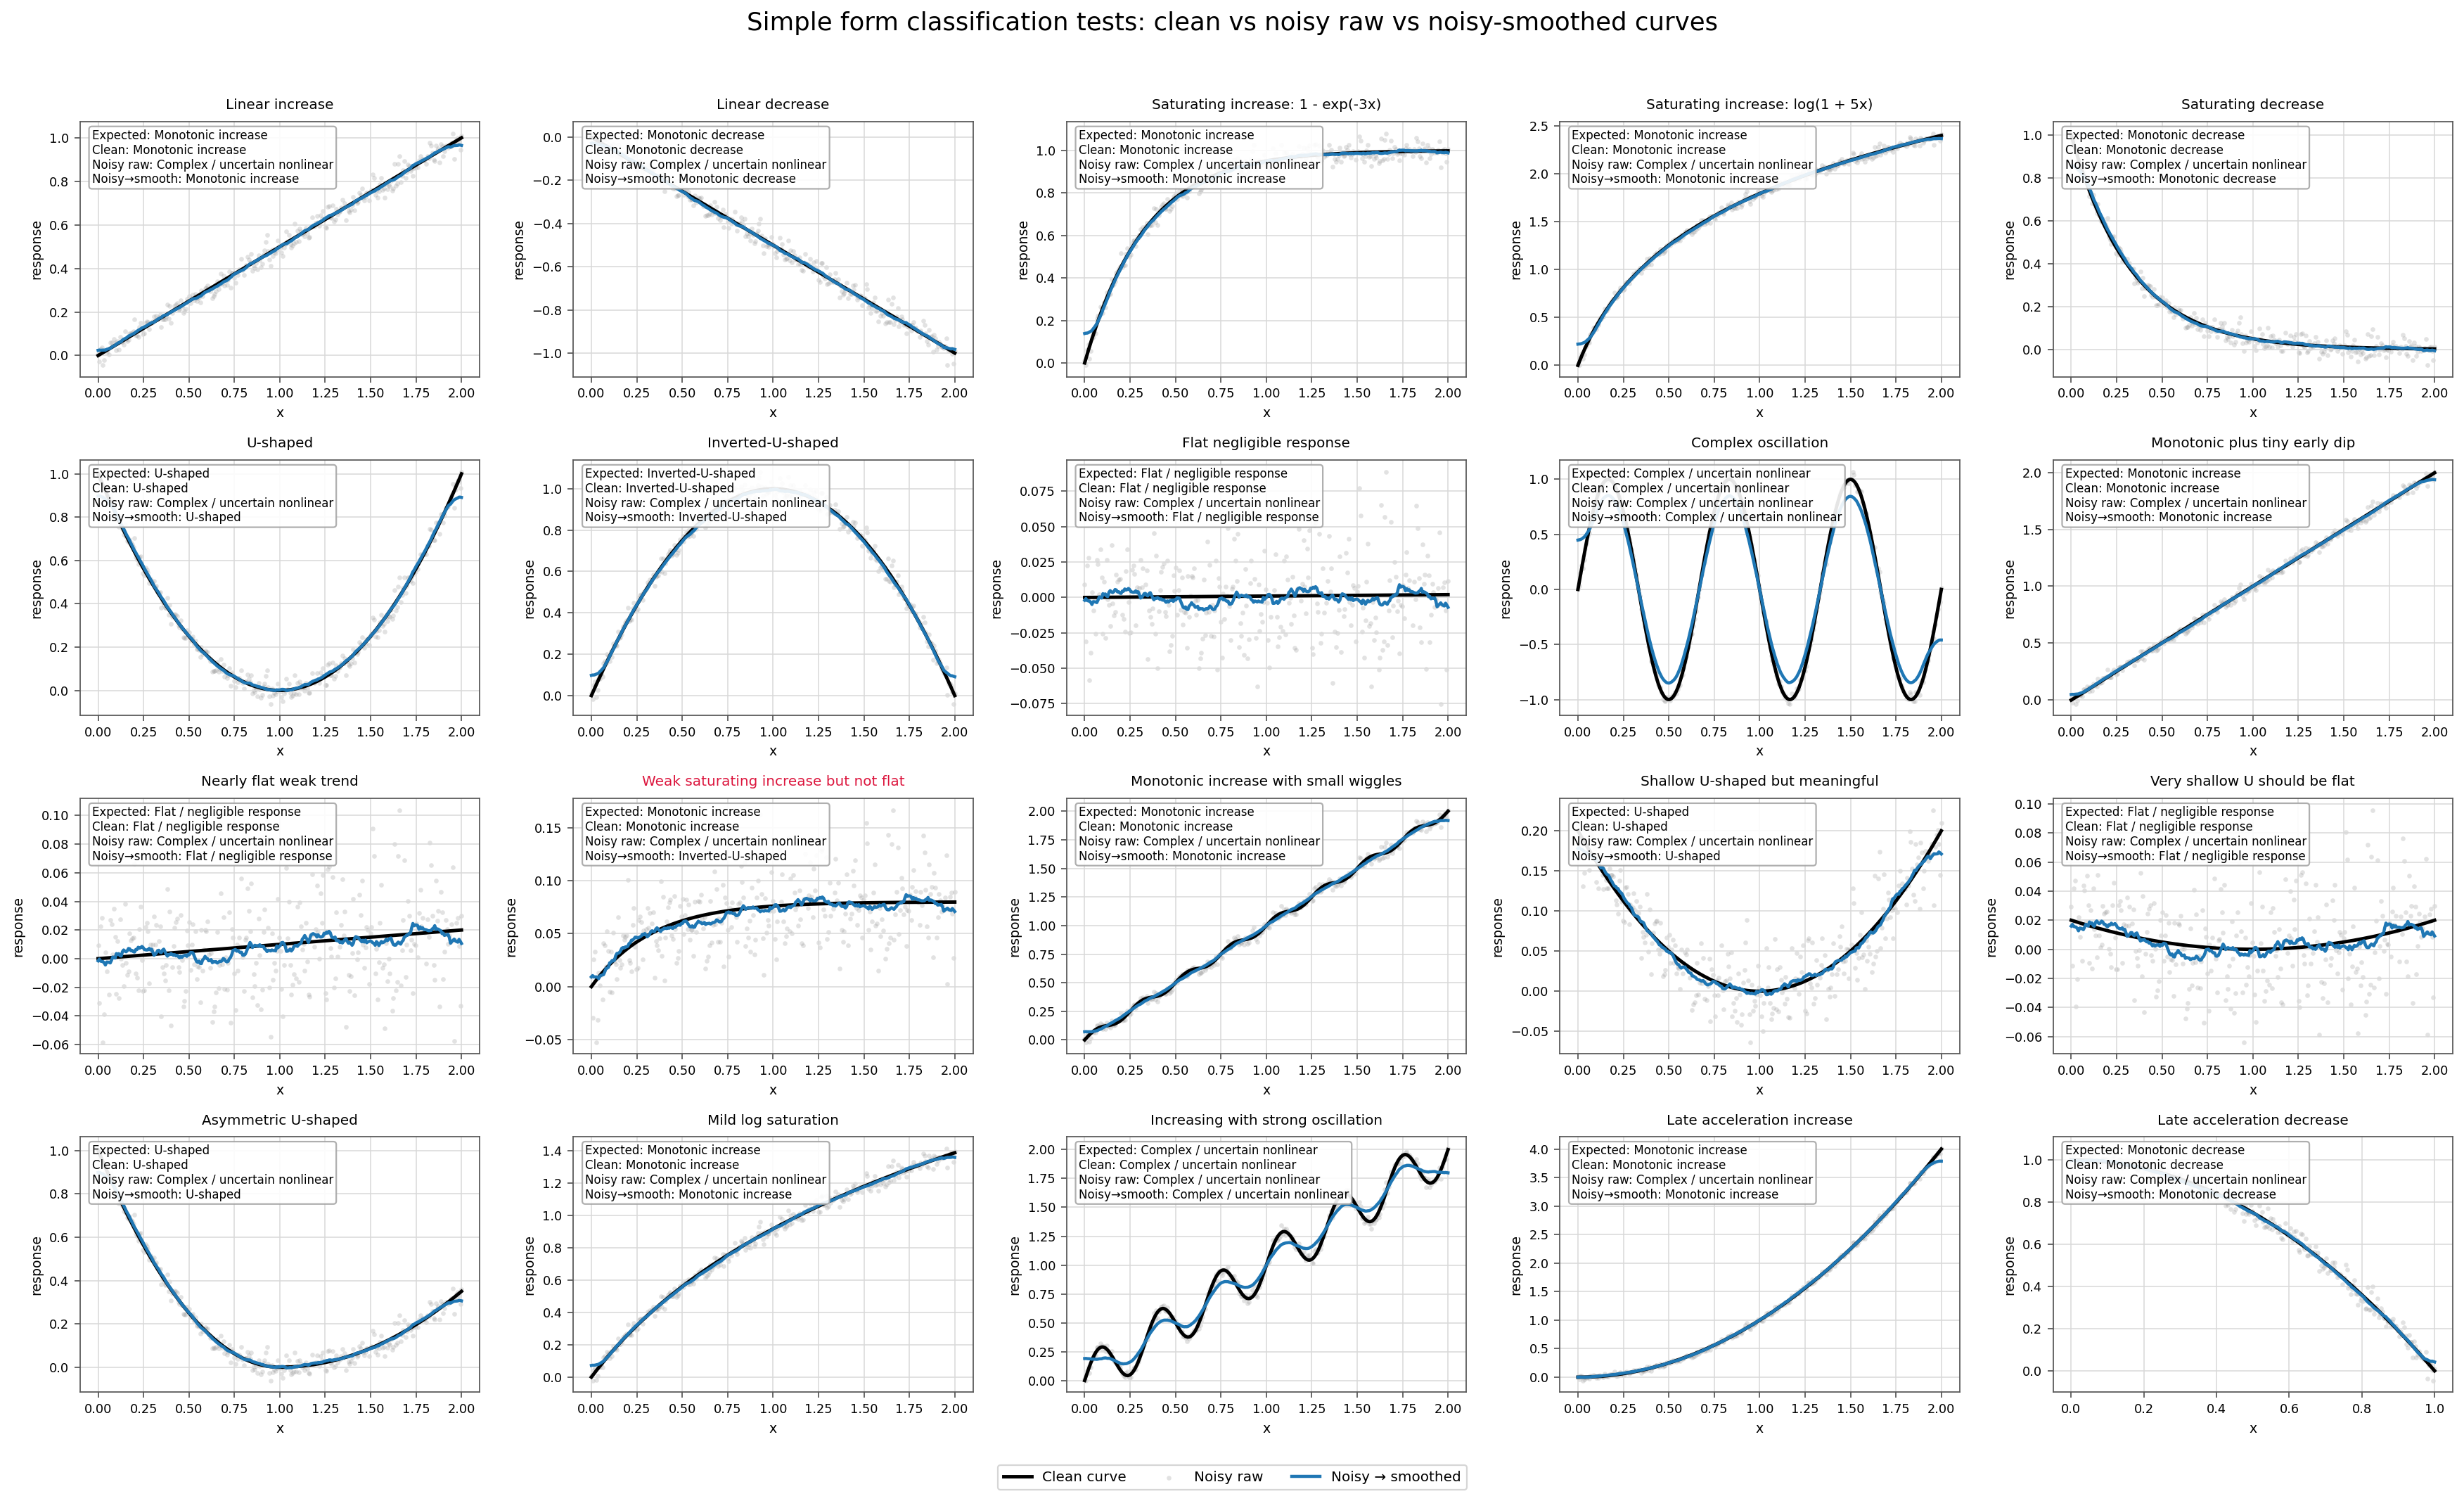

In [60]:
plot_test_comparison_simple(
    test_cases=all_test_cases_simple,
    noise=0.03,
    smooth_window=31,
    n_cols=5,
    figsize_per_panel=(4.4, 3.3),
    text_fontsize=7.5,
    title_fontsize=9,
    axis_label_fontsize=8.5,
    tick_fontsize=8,
    legend_fontsize=9
)

In [61]:
def classify_esm_curves_simple(curve_results):
    records = []

    for key, result in curve_results.items():
        x_label, y_label, model_name = key

        y_raw = result["y_raw"]
        y_obs_std = np.nanstd(y_raw)

        for method, curve in result["curves"].items():
            shape_result = classify_curve_shape_simple(
                curve["x"],
                curve["y"],
                y_obs_std=y_obs_std
            )

            records.append({
                "model": model_name,
                "x": x_label,
                "y": y_label,
                "method": method,
                "shape_type": shape_result.get("shape_type", np.nan),

                # diagnostic metrics
                "y_range_to_obs_std": shape_result.get("y_range_to_obs_std", np.nan),
                "net_change": shape_result.get("net_change", np.nan),
                "net_change_ratio": shape_result.get("net_change_ratio", np.nan),
                "pos_fraction": shape_result.get("pos_fraction", np.nan),
                "neg_fraction": shape_result.get("neg_fraction", np.nan),
                "flat_fraction": shape_result.get("flat_fraction", np.nan),
                "n_sign_changes": shape_result.get("n_sign_changes", np.nan),
                "roughness_ratio": shape_result.get("roughness_ratio", np.nan),

                # U / inverted-U diagnostics
                "left_drop_to_min": shape_result.get("left_drop_to_min", np.nan),
                "right_rise_from_min": shape_result.get("right_rise_from_min", np.nan),
                "left_rise_to_max": shape_result.get("left_rise_to_max", np.nan),
                "right_drop_from_max": shape_result.get("right_drop_from_max", np.nan),
                "left_neg_or_flat": shape_result.get("left_neg_or_flat", np.nan),
                "right_pos_or_flat": shape_result.get("right_pos_or_flat", np.nan),
                "left_pos_or_flat": shape_result.get("left_pos_or_flat", np.nan),
                "right_neg_or_flat": shape_result.get("right_neg_or_flat", np.nan),
                "u_shape_candidate": shape_result.get("u_shape_candidate", np.nan),
                "inverted_u_candidate": shape_result.get("inverted_u_candidate", np.nan),
            })

    return pd.DataFrame(records)

In [56]:
shape_df_simple = classify_esm_curves_simple(curve_results)

shape_df_simple

,model,x,y,method,shape_type,y_range_to_obs_std,net_change,net_change_ratio,pos_fraction,neg_fraction,...,left_drop_to_min,right_rise_from_min,left_rise_to_max,right_drop_from_max,left_neg_or_flat,right_pos_or_flat,left_pos_or_flat,right_neg_or_flat,u_shape_candidate,inverted_u_candidate
0,CLASSIC,P,T,Equal-width bins,Complex / uncertain nonlinear,1.845239,1.000000,1.000000,0.555556,0.333333,...,0.0,1.000000,1.0,0.000000,0.0,0.666667,0.666667,0.000000,False,False
1,CLASSIC,P,T,Equal-count bins,Monotonic increase,1.668350,0.984962,0.984962,0.888889,0.111111,...,0.0,0.984962,1.0,0.015038,0.0,0.888889,1.000000,1.000000,False,False
2,CLASSIC,P,T,LOWESS,Monotonic increase,2.092985,0.978668,0.978668,0.843693,0.085508,...,0.0,0.978668,1.0,0.021332,0.0,0.914492,0.999029,1.000000,False,False
3,CLASSIC,P,T,Polynomial degree 3,Complex / uncertain nonlinear,2.187359,0.975363,0.975363,0.675585,0.267559,...,0.0,0.975363,1.0,0.024637,0.0,0.732441,1.000000,0.837838,False,False
4,CLASSIC,P,T,GAM,Complex / uncertain nonlinear,2.602444,1.000000,1.000000,0.702341,0.217391,...,0.0,1.000000,1.0,0.000000,0.0,0.782609,0.782609,0.000000,False,False
5,CLASSIC,P,T,Piecewise linear,Monotonic increase,2.184151,1.000000,1.000000,1.000000,0.000000,...,0.0,1.000000,1.0,0.000000,0.0,1.000000,1.000000,0.000000,False,False
6,CLASSIC,P,T,Symbolic regression,Monotonic increase,2.776683,1.000000,1.000000,1.000000,0.000000,...,0.0,1.000000,1.0,0.000000,0.0,1.000000,1.000000,0.000000,False,False
7,LPJ-GUESS,P,T,Equal-width bins,Monotonic increase,2.308453,1.000000,1.000000,0.888889,0.111111,...,0.0,1.000000,1.0,0.000000,0.0,0.888889,0.888889,0.000000,False,False
8,LPJ-GUESS,P,T,Equal-count bins,Monotonic increase,2.307539,1.000000,1.000000,1.000000,0.000000,...,0.0,1.000000,1.0,0.000000,0.0,1.000000,1.000000,0.000000,False,False
9,LPJ-GUESS,P,T,LOWESS,Monotonic increase,2.575243,0.976876,0.976876,0.937551,0.054869,...,0.0,0.976876,1.0,0.023124,0.0,0.945131,1.000000,0.990000,False,False


In [63]:
shape_table_long = shape_df_simple.copy()

shape_table_long["model_short"] = shape_table_long["model"].replace({
    "CLASSIC": "CLASSIC",
    "LPJ-GUESS": "LPJ"
})

shape_table_long["relation_col"] = (
    shape_table_long["model_short"]
    + ": "
    + shape_table_long["x"]
    + " \u2192 "
    + shape_table_long["y"]
)

method_name_map = {
    "Equal-width bins": "Equal-width bins",
    "Equal-count bins": "Equal-count bins",
    "LOWESS": "LOWESS",
    "Polynomial degree 3": "Polynomial regression",
    "GAM": "Generalized Additive Model (GAM)",
    "Piecewise linear": "Piecewise linear regression",
    "Symbolic regression": "Symbolic regression"
}

shape_table_long["Method"] = (
    shape_table_long["method"]
    .map(method_name_map)
    .fillna(shape_table_long["method"])
)

shape_table_method_simple = shape_table_long.pivot_table(
    index="Method",
    columns="relation_col",
    values="shape_type",
    aggfunc="first"
).reset_index()

method_order = [
    "Equal-width bins",
    "Equal-count bins",
    "LOWESS",
    "Polynomial regression",
    "Generalized Additive Model (GAM)",
    "Piecewise linear regression",
    "Symbolic regression"
]

shape_table_method_simple["Method"] = pd.Categorical(
    shape_table_method_simple["Method"],
    categories=method_order,
    ordered=True
)

shape_table_method_simple = (
    shape_table_method_simple
    .sort_values("Method")
    .reset_index(drop=True)
)

column_order = [
    "Method",
    "CLASSIC: LAI \u2192 T",
    "CLASSIC: P \u2192 T",
    "LPJ: LAI \u2192 T",
    "LPJ: P \u2192 T"
]

available_columns = [
    col for col in column_order
    if col in shape_table_method_simple.columns
]

shape_table_method_simple = shape_table_method_simple[available_columns]

shape_table_method_simple

relation_col,Method,CLASSIC: LAI → T,CLASSIC: P → T,LPJ: LAI → T,LPJ: P → T
0,Equal-width bins,Monotonic increase,Complex / uncertain nonlinear,Monotonic increase,Monotonic increase
1,Equal-count bins,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase
2,LOWESS,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase
3,Polynomial regression,Monotonic increase,Complex / uncertain nonlinear,Monotonic increase,Inverted-U-shaped
4,Generalized Additive Model (GAM),Monotonic increase,Complex / uncertain nonlinear,Monotonic increase,Complex / uncertain nonlinear
5,Piecewise linear regression,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase
6,Symbolic regression,Monotonic increase,Monotonic increase,Monotonic increase,Monotonic increase
